# Features Extraídas del Modelo nnELM

## Mapas disponibles

| Mapa | Shape | Descripción |
|---|---|---|
| `saliencia` | `(H, W)` | Prior bottom-up (DeepGaze II) |
| `similitud` | `(H, W)` | Target Similarity Map (ResNeXt101) |
| `visual_evidence` | `(n_fix, 24, 32)` | `max(W·d², W·d')` — Eq. 8 del paper |
| `posterior` | `(n_fix, 24, 32)` | Creencia bayesiana acumulada tras cada fijación |
| `entropy_map` | `(n_fix, 24, 32)` | `-p·log(p)` celda a celda del posterior |
| `expected_ig_map` | `(n_fix, 24, 32)` | `½ · ∑ p_i(T) · d²_ik(T+1)` — Eq. 6 del paper |

---

## Features por fijación

### 1. Información Bottom-Up
**Descripción:** características visuales generales de la escena en el punto fijado.

| Feature | Cálculo |
|---|---|
| `saliencia_media` | `mean(saliencia[y*32:(y+1)*32, x*32:(x+1)*32])` |
| `saliencia_mediana` | `median(saliencia[y*32:(y+1)*32, x*32:(x+1)*32])` |
| `saliencia_pixel` | `saliencia[y_pixel, x_pixel]` — coordenada real del sujeto |

---

### 2. Similitud con el Target
**Descripción:** cuán similar es la región observada al target en memoria.

| Feature | Cálculo |
|---|---|
| `similitud_media` | `mean(similitud[y*32:(y+1)*32, x*32:(x+1)*32])` |
| `similitud_mediana` | `median(similitud[y*32:(y+1)*32, x*32:(x+1)*32])` |
| `similitud_pixel` | `similitud[y_pixel, x_pixel]` — coordenada real del sujeto |

---

### 3. Evidencia Visual
**Descripción:** valor de la evidencia visual acumulada en la celda fijada.

| Feature | Cálculo |
|---|---|
| `ve_at_fix` | `visual_evidence[t, y, x]` |

---

### 4. Competencia Foveal-Periférica
**Descripción:** tensión entre información foveal y periférica. Mide cuántos picos compiten en el mapa `max(W·d², W·d')`.

| Feature | Cálculo |
|---|---|
| `competencia_fp_var` | `var(visual_evidence[t])` sobre todas las celdas |
| `competencia_fp_media` | `mean(visual_evidence[t])` sobre todas las celdas |
| `competencia_fp_max` | `max(visual_evidence[t])` sobre todas las celdas |

---

### 5. Probabilidad Posterior
**Descripción:** creencia bayesiana del modelo en la celda fijada tras `t` fijaciones.

| Feature | Cálculo |
|---|---|
| `posterior_at_fix` | `posterior[t, y, x]` |

---

### 6. Entropía Global del Posterior
**Descripción:** incertidumbre global del modelo en el instante `t`. Decrece a medida que el modelo acumula evidencia.

| Feature | Cálculo |
|---|---|
| `entropia_posterior` | `∑_{i,j} entropy_map[t, i, j]` = `-∑ p·log(p)` |

---

### 7. Ganancia de Información
**Descripción:** cuánta información nueva aportó la fijación `t` respecto a la creencia anterior.

| Feature | Cálculo |
|---|---|
| `ganancia_informacion` | `KL(P_t ∥ P_{t-1}) = ∑ p_t · log(p_t / p_{t-1})` — `None` en `t=0` |

---

### 8. Gap de Entropía con el Óptimo
**Descripción:** cuán lejos estuvo el sujeto de la decisión óptima del modelo en términos de ganancia de información esperada.

| Feature | Cálculo |
|---|---|
| `eig_optimo` | `max(expected_ig_map[t])` |
| `eig_en_fijacion` | `expected_ig_map[t, y, x]` |
| `gap_entropia` | `eig_optimo - eig_en_fijacion` |

---

### 9. Distancia con la Decisión del Modelo
**Descripción:** distancia espacial entre donde miró el sujeto y donde hubiera mirado el modelo.

| Feature | Cálculo |
|---|---|
| `modelo_fix_y`, `modelo_fix_x` | `argmax(expected_ig_map[t])` |
| `distancia_grilla` | `√((y - y_modelo)² + (x - x_modelo)²)` en celdas |
| `distancia_pixels` | `distancia_grilla × 32` en píxeles |

---

### 10. Competencia en el Mapa de EIG (Ratio)
**Descripción:** si hay varios lugares igualmente buenos compitiendo por la atención. Ratio cercano a 1 indica fuerte competencia.

| Feature | Cálculo |
|---|---|
| `competencia_ratio` | `segundo_mayor(expected_ig_map[t]) / mayor(expected_ig_map[t])` |

---

### 11. Competencia en el Mapa de EIG (Densidad)
**Descripción:** cantidad de celdas dentro del 5% del valor máximo del EIG map.

| Feature | Cálculo |
|---|---|
| `competencia_densidad` | `∑ celdas donde expected_ig_map[t] ≥ 0.95 · max` |
| `competencia_densidad_norm` | `competencia_densidad / 768` — proporción sobre el total de celdas |

---

## Features constantes por trial

### 12. Entropía del Prior
**Descripción:** incertidumbre antes de iniciar la búsqueda. Constante a lo largo del trial.

| Feature | Cálculo |
|---|---|
| `entropia_prior_saliencia` | `-∑ p·log(p)` donde `p = saliencia / saliencia.sum()` |
| `entropia_prior_modelo` | `-∑ p·log(p)` donde `p = posterior[0]` |

In [1]:
from configuraciones import *
import Utils.map_loader as ml
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import numpy as np
from scipy import stats
import json, os, warnings

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 100,
                     'axes.spines.top': False, 'axes.spines.right': False})
random.seed(42)
np.random.seed(42)

FEATURES_PATH = 'Features'
CELL_SIZE = 32

In [2]:
def cargar_todos_los_features():
    rows = []
    for imagen_stem in sorted(os.listdir(FEATURES_PATH)):
        imagen = imagen_stem + '.jpg'
        for sujeto in sorted(os.listdir(f'{FEATURES_PATH}/{imagen_stem}')):
            json_path = f'{FEATURES_PATH}/{imagen_stem}/{sujeto}/features.json'
            if not os.path.exists(json_path):
                continue
            with open(json_path) as f:
                data = json.load(f)
            for fij in data['fijaciones']:
                rows.append({
                    'imagen': imagen, 'sujeto': sujeto,
                    'target_stim': data['target_stim'],
                    'target_found': data['target_found'],
                    'mss': len(data['memory_set']),
                    **fij
                })
    df = pd.DataFrame(rows)
    df['ganancia_informacion'] = pd.to_numeric(df['ganancia_informacion'], errors='coerce')
    return df

df = cargar_todos_los_features()
print(f'Filas totales : {len(df):,}')
print(f'Imágenes      : {df["imagen"].nunique()}')
print(f'Sujetos       : {df["sujeto"].nunique()}')
print(f'target_found  : {df.groupby("target_found").size().to_dict()}')
FEAT_COLS = [c for c in df.columns if c not in
             ['imagen','sujeto','target_stim','target_found','mss',
              'fixation','fix_y','fix_x','modelo_fix_y','modelo_fix_x']]
print(f'Features ({len(FEAT_COLS)}): {FEAT_COLS}')

Filas totales : 47,628
Imágenes      : 102
Sujetos       : 44
target_found  : {False: 15032, True: 32596}
Features (28): ['saliencia_media', 'saliencia_mediana', 'saliencia_pixel', 'similitud_media', 'similitud_mediana', 'similitud_pixel', 'evidencia_visual', 'competencia_fp_var', 'competencia_fp_media', 'competencia_fp_max', 'posterior', 'entropia_prior_saliencia', 'entropia_prior_modelo', 'entropia_posterior', 'ganancia_informacion', 'eig_optimo', 'eig_en_fijacion', 'gap_entropia', 'distancia_grilla', 'distancia_pixels', 'competencia_ratio_mayor', 'competencia_ratio_segundo_mayor', 'competencia_ratio', 'competencia_densidad', 'competencia_densidad_norm', 'saliencia_media_orig', 'saliencia_mediana_orig', 'saliencia_pixel_orig']


In [19]:
# ── Helpers de visualización ──────────────────────────────────────────────────

def cargar_trial(imagen, sujeto):
    mapas = ml.cargar_mapas_humanos(sujeto, imagen)
    stem  = imagen.replace('.jpg', '')
    with open(f'{FEATURES_PATH}/{stem}/{sujeto}/features.json') as f:
        feats = json.load(f)
    return mapas, feats

def fijaciones_en_pixeles(mapas):
    ys = np.array(mapas['fixations_y']) * CELL_SIZE + CELL_SIZE // 2
    xs = np.array(mapas['fixations_x']) * CELL_SIZE + CELL_SIZE // 2
    return ys, xs

def mostrar_fijaciones(ax, img, ys, xs, valores=None, cmap='plasma',
                       titulo='', label_colorbar=''):
    """Imagen con scanpath coloreado por una feature."""
    ax.imshow(img)
    n = len(ys)
    if valores is None:
        valores = np.arange(n, dtype=float)
    vmin, vmax = np.nanmin(valores), np.nanmax(valores) + 1e-12
    for i in range(1, n):
        ax.plot([xs[i-1], xs[i]], [ys[i-1], ys[i]],
                '-', color='white', alpha=0.45, linewidth=1, zorder=3)
    sc = ax.scatter(xs, ys, c=valores, cmap=cmap, vmin=vmin, vmax=vmax,
                    s=150, zorder=5, edgecolors='white', linewidths=0.8)
    for i in range(n):
        ax.text(xs[i]+7, ys[i]-8, str(i), fontsize=7, color='white',
                zorder=6, fontweight='bold')
    ax.set_title(titulo, fontsize=9)
    ax.axis('off')
    return sc

def superponer_mapa(ax, img, mapa, alpha=0.55, cmap='inferno', titulo=''):
    ax.imshow(img)
    h, w = img.shape[:2]
    mapa_resize = np.array(__import__('PIL').Image.fromarray(
        ((mapa - mapa.min()) / (mapa.max() - mapa.min() + 1e-12) * 255).astype(np.uint8)
    ).resize((w, h), __import__('PIL').Image.LANCZOS)) / 255.0
    ax.imshow(mapa_resize, cmap=cmap, alpha=alpha)
    ax.set_title(titulo, fontsize=9); ax.axis('off')

# ── Trial de ejemplo fijo para toda la Sección 1 ─────────────────────────────
_cand = (df[df['target_found'] == True]
         .groupby(['imagen', 'sujeto'])
         .filter(lambda g: len(g) >= 6)
         .groupby(['imagen', 'sujeto']).first().reset_index())
_row = _cand.sample(1, random_state=2).iloc[0]
# IMAGEN_EJ, SUJETO_EJ = _row['imagen'], _row['sujeto']
IMAGEN_EJ, SUJETO_EJ = 'cmp_building_020_cat_007.jpg', 'et_179678'
print(f'Trial de ejemplo: {SUJETO_EJ}  |  {IMAGEN_EJ}')
mapas_ej, feats_ej = cargar_trial(IMAGEN_EJ, SUJETO_EJ)
img_ej   = ml.cargar_imagen_original(IMAGEN_EJ)
ys_ej, xs_ej = fijaciones_en_pixeles(mapas_ej)
n_ej = len(ys_ej)
print(f'Fijaciones: {n_ej}  |  target_found: {mapas_ej["target_found"]}  |  MSS: {len(mapas_ej["memory_set"])}')

Trial de ejemplo: et_179678  |  cmp_building_020_cat_007.jpg
Fijaciones: 9  |  target_found: True  |  MSS: 4


---
## Sección 1: Validación Individual de Features

Para cada feature se muestra:
1. **Visualización sobre imagen**: scanpath coloreado por el valor de la feature
   (números = orden de fijación, color = valor de la feature).
2. **Evolución temporal**: cómo cambia la feature a lo largo del trial.
3. **Distribución global**: distribución del valor de la feature en todos los trials.

### 1. Información Bottom-Up — Saliencia

**Qué mide:** relevancia visual de la celda fijada según el mapa de saliencia DeepGaze II.

**Qué esperar:**
- Los valores deberían ser altos en las **primeras fijaciones** (guiadas por bottom-up) y
  decrecer hacia fijaciones tardías (guiadas por la búsqueda del target).
- El mapa de saliencia debería superponerse visualmente con las fijaciones tempranas.

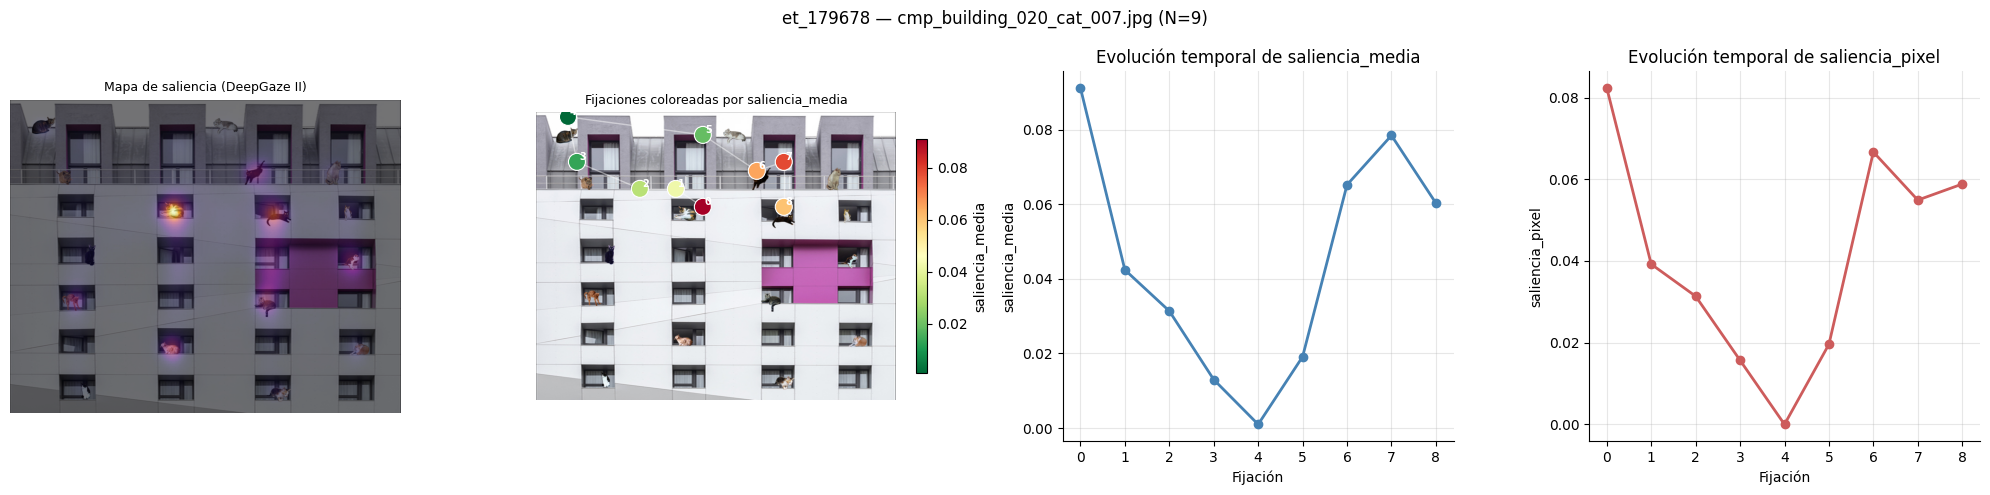

In [20]:
# 1. Cargar las features
sal_vals_ej = np.array([f['saliencia_media'] for f in feats_ej['fijaciones']])
sal_vals_ej_2 = np.array([f['saliencia_pixel'] for f in feats_ej['fijaciones']])

# 2. ALINEACIÓN CRÍTICA: Forzar que todas las listas tengan el mismo largo
# Determinamos el largo mínimo entre las coordenadas (x,y) y las features
min_len = min(len(xs_ej), len(sal_vals_ej))

xs_plot = xs_ej[:min_len]
ys_plot = ys_ej[:min_len]
sal_vals_plot = sal_vals_ej[:min_len]
sal_vals_2_plot = sal_vals_ej_2[:min_len]

n_puntos = min_len # Reemplaza a n_ej para los ejes X de los plots

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# a) Mapa de saliencia superpuesto
superponer_mapa(axes[0], img_ej, sal_ej, cmap='inferno',
                titulo='Mapa de saliencia (DeepGaze II)')

# b) Scanpath coloreado por saliencia_media (USANDO LISTAS ALINEADAS)
sc = mostrar_fijaciones(axes[1], img_ej, ys_plot, xs_plot,
                         valores=sal_vals_plot, cmap='RdYlGn_r',
                         titulo='Fijaciones coloreadas por saliencia_media')
plt.colorbar(sc, ax=axes[1], fraction=0.03, label='saliencia_media')

# c) Evolución temporal saliencia_media
axes[2].plot(range(n_puntos), sal_vals_plot, 'o-', color='steelblue', linewidth=2)
axes[2].set_xlabel('Fijación'); axes[2].set_ylabel('saliencia_media')
axes[2].set_title('Evolución temporal de saliencia_media')
axes[2].grid(True, alpha=0.3)

# d) Evolución temporal saliencia_pixel
axes[3].plot(range(n_puntos), sal_vals_2_plot, 'o-', color='indianred', linewidth=2)
axes[3].set_xlabel('Fijación'); axes[3].set_ylabel('saliencia_pixel')
axes[3].set_title('Evolución temporal de saliencia_pixel')
axes[3].grid(True, alpha=0.3)

plt.suptitle(f'{SUJETO_EJ} — {IMAGEN_EJ} (N={n_puntos})', fontsize=12)
plt.tight_layout(); plt.show()

Mann-Whitney U: U=248565533.5, p=0.0104
Media encontrado=0.0626 | Media no encontrado=0.0628


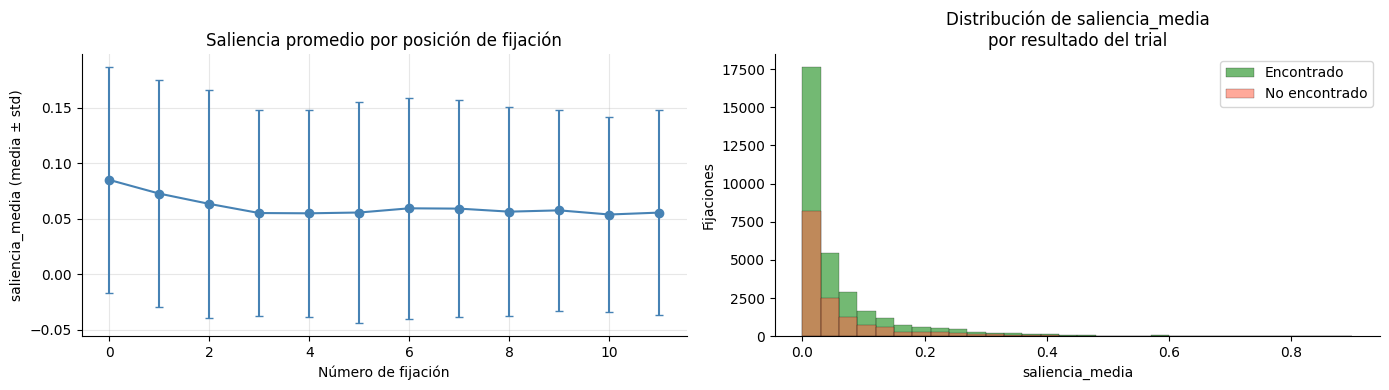

In [13]:
# Distribución global: saliencia vs. número de fijación
sal_df = df[['fixation', 'saliencia_media', 'target_found']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Mediana de saliencia por posición de fijación (primeras 12)
sal_by_fix = sal_df[sal_df['fixation'] < 12].groupby('fixation')['saliencia_media']
axes[0].errorbar(sal_by_fix.mean().index,
                 sal_by_fix.mean().values,
                 yerr=sal_by_fix.std().values,
                 fmt='o-', color='steelblue', capsize=3)
axes[0].set_xlabel('Número de fijación'); axes[0].set_ylabel('saliencia_media (media ± std)')
axes[0].set_title('Saliencia promedio por posición de fijación')
axes[0].grid(True, alpha=0.3)

# Distribución por target_found
for tf, lbl, col in [(True,'Encontrado','green'),(False,'No encontrado','tomato')]:
    vals = sal_df[sal_df['target_found']==tf]['saliencia_media']
    axes[1].hist(vals, bins=30, alpha=0.55, label=lbl, color=col, edgecolor='k', linewidth=0.3)
axes[1].set_xlabel('saliencia_media'); axes[1].set_ylabel('Fijaciones')
axes[1].set_title('Distribución de saliencia_media\npor resultado del trial')
axes[1].legend()

# Test estadístico
g_found    = sal_df[sal_df['target_found']==True]['saliencia_media']
g_notfound = sal_df[sal_df['target_found']==False]['saliencia_media']
t, p = stats.mannwhitneyu(g_found, g_notfound, alternative='two-sided')
print(f'Mann-Whitney U: U={t:.1f}, p={p:.4f}')
print(f'Media encontrado={g_found.mean():.4f} | Media no encontrado={g_notfound.mean():.4f}')

plt.tight_layout(); plt.show()

### 2. Similitud con el Target

**Qué mide:** qué tan parecida es la región fijada al target buscado, según ResNeXt101.

**Qué esperar:**
- Valores altos cuando el sujeto fija **cerca del target**.
- En trials donde el target fue **encontrado**, el valor debería subir hacia las últimas fijaciones.
- En trials **no encontrados**, los valores deberían permanecer bajos.

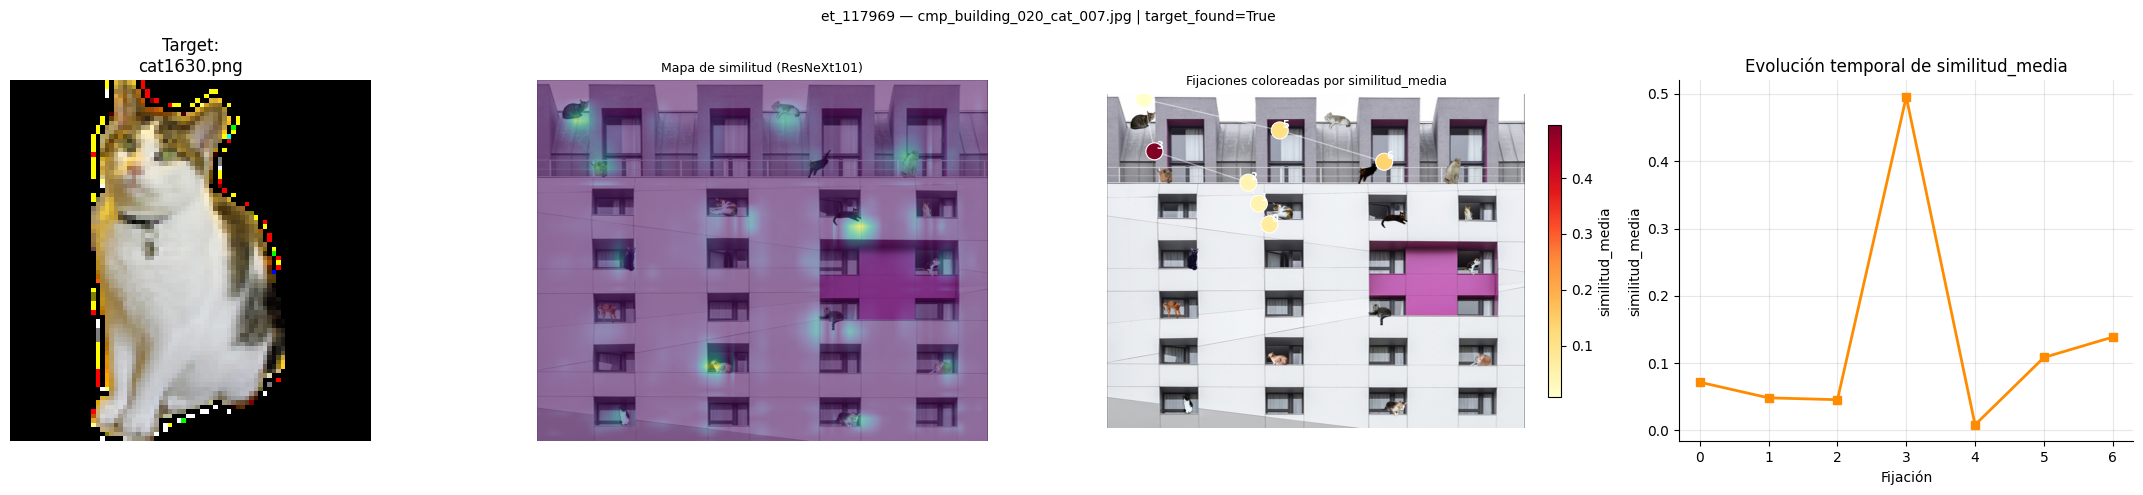

In [6]:
sim_ej    = ml.cargar_mapa_similitud(IMAGEN_EJ, mapas_ej['target_stim'])
sim_vals  = np.array([f['similitud_media'] for f in feats_ej['fijaciones']])
img_tgt   = ml.cargar_imagen_target(mapas_ej['target_stim'])

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# a) Target
axes[0].imshow(img_tgt); axes[0].set_title(f'Target:\n{mapas_ej["target_stim"]}')
axes[0].axis('off')

# b) Mapa de similitud
superponer_mapa(axes[1], img_ej, sim_ej, cmap='viridis',
                titulo='Mapa de similitud (ResNeXt101)')

# c) Fijaciones coloreadas por similitud
sc = mostrar_fijaciones(axes[2], img_ej, ys_ej, xs_ej,
                         valores=sim_vals, cmap='YlOrRd',
                         titulo='Fijaciones coloreadas por similitud_media')
plt.colorbar(sc, ax=axes[2], fraction=0.03, label='similitud_media')

# d) Evolución temporal
axes[3].plot(range(n_ej), sim_vals, 's-', color='darkorange', linewidth=2)
axes[3].set_xlabel('Fijación'); axes[3].set_ylabel('similitud_media')
axes[3].set_title('Evolución temporal de similitud_media')
axes[3].grid(True, alpha=0.3)

plt.suptitle(f'{SUJETO_EJ} — {IMAGEN_EJ} | target_found={mapas_ej["target_found"]}', fontsize=10)
plt.tight_layout(); plt.show()

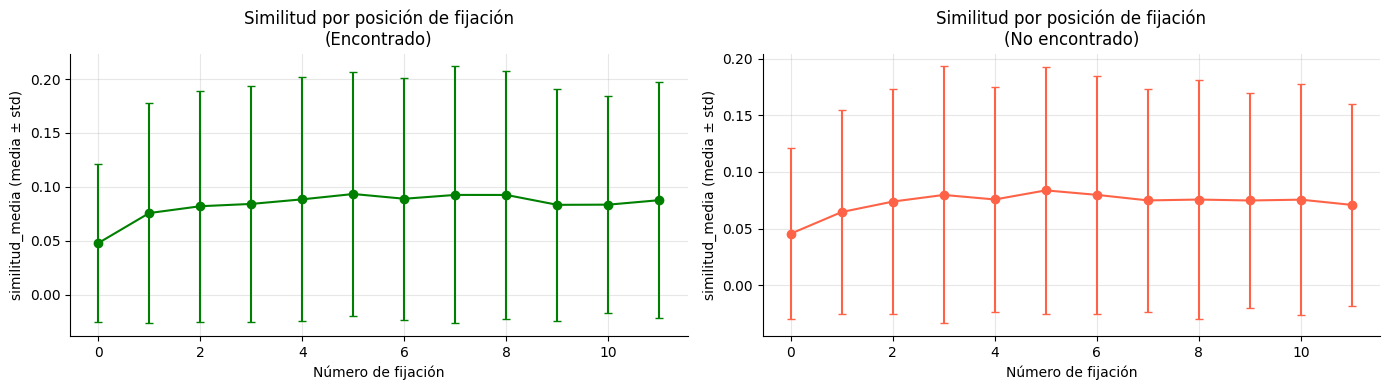

Correlación fijación vs similitud_media: 0.027


In [7]:
# Similitud media por fijación: ¿aumenta hacia el final del trial?
sim_df = df[['fixation', 'similitud_media', 'target_found']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for tf, lbl, col, ax in [(True,'Encontrado','green', axes[0]),
                          (False,'No encontrado','tomato', axes[1])]:
    sub = sim_df[sim_df['target_found']==tf]
    grp = sub[sub['fixation'] < 12].groupby('fixation')['similitud_media']
    ax.errorbar(grp.mean().index, grp.mean().values, yerr=grp.std().values,
                fmt='o-', color=col, capsize=3)
    ax.set_xlabel('Número de fijación'); ax.set_ylabel('similitud_media (media ± std)')
    ax.set_title(f'Similitud por posición de fijación\n({lbl})')
    ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Sanity: la fijación SOBRE el target debería tener similitud alta
# (si fix_y/fix_x coincide con la celda del target)
print('Correlación fijación vs similitud_media:',
      df[['fixation','similitud_media']].corr().iloc[0,1].round(3))

### 3. Evidencia Visual

**Qué mide:** valor de la evidencia visual acumulada `W` en la celda fijada. Cuantifica
cuánta información sensorial ha acumulado el modelo en esa posición.

**Qué esperar:**
- Debería **aumentar** con el número de fijación (la evidencia se acumula).
- Valores altos cuando el sujeto revisita o fija cerca del target.

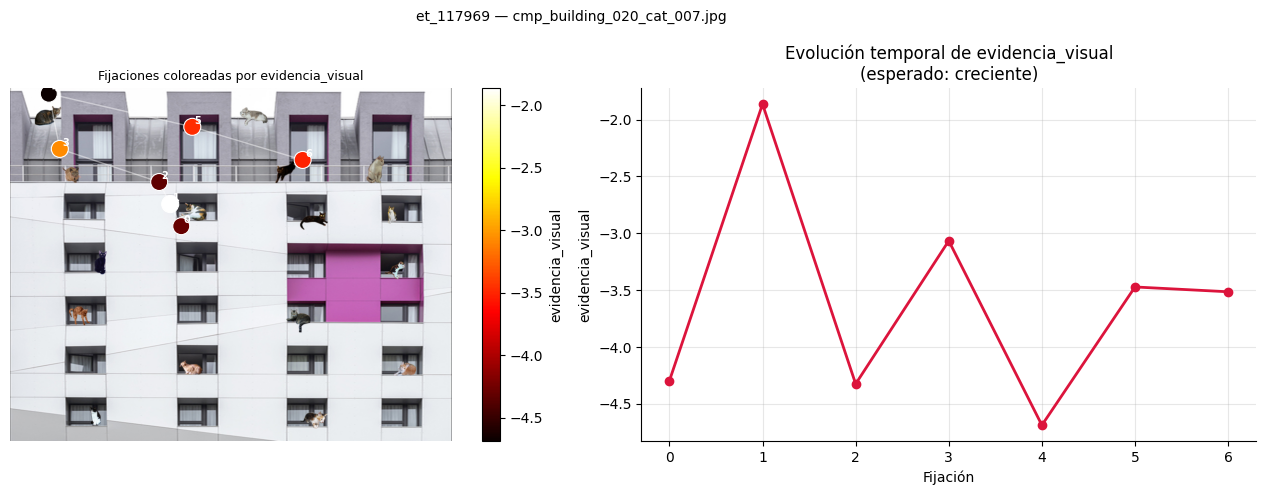

Trials donde evidencia_visual final > inicial: 2458/4442 (55%)


In [8]:
ve_vals = np.array([f['evidencia_visual'] for f in feats_ej['fijaciones']])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# a) Scanpath coloreado por evidencia_visual
sc = mostrar_fijaciones(axes[0], img_ej, ys_ej, xs_ej,
                         valores=ve_vals, cmap='hot',
                         titulo='Fijaciones coloreadas por evidencia_visual')
plt.colorbar(sc, ax=axes[0], fraction=0.03, label='evidencia_visual')

# b) Evolución temporal
axes[1].plot(range(n_ej), ve_vals, 'o-', color='crimson', linewidth=2)
axes[1].set_xlabel('Fijación'); axes[1].set_ylabel('evidencia_visual')
axes[1].set_title('Evolución temporal de evidencia_visual\n(esperado: creciente)')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'{SUJETO_EJ} — {IMAGEN_EJ}', fontsize=10)
plt.tight_layout(); plt.show()

# Sanity: ¿crece monótonamente?
n_creciente = sum(1 for s, g in df.groupby(['imagen','sujeto'])
                  if len(g) > 1 and
                  g.sort_values('fixation')['evidencia_visual'].iloc[-1] >
                  g.sort_values('fixation')['evidencia_visual'].iloc[0])
n_total = df.groupby(['imagen','sujeto']).ngroups
print(f'Trials donde evidencia_visual final > inicial: {n_creciente}/{n_total} ({100*n_creciente/n_total:.0f}%)')

### 4. Competencia Foveal-Periférica

**Qué mide:** tensión en el mapa de evidencia visual entre señales foveales y periféricas.
- `competencia_fp_var`: cuán dispersa es la evidencia (alta = picos bien separados).
- `competencia_fp_max`: amplitud del pico máximo.

**Qué esperar:**
- Alta varianza puede indicar que una región domina claramente el mapa.
- Aumenta conforme el modelo acumula evidencia sobre el target.

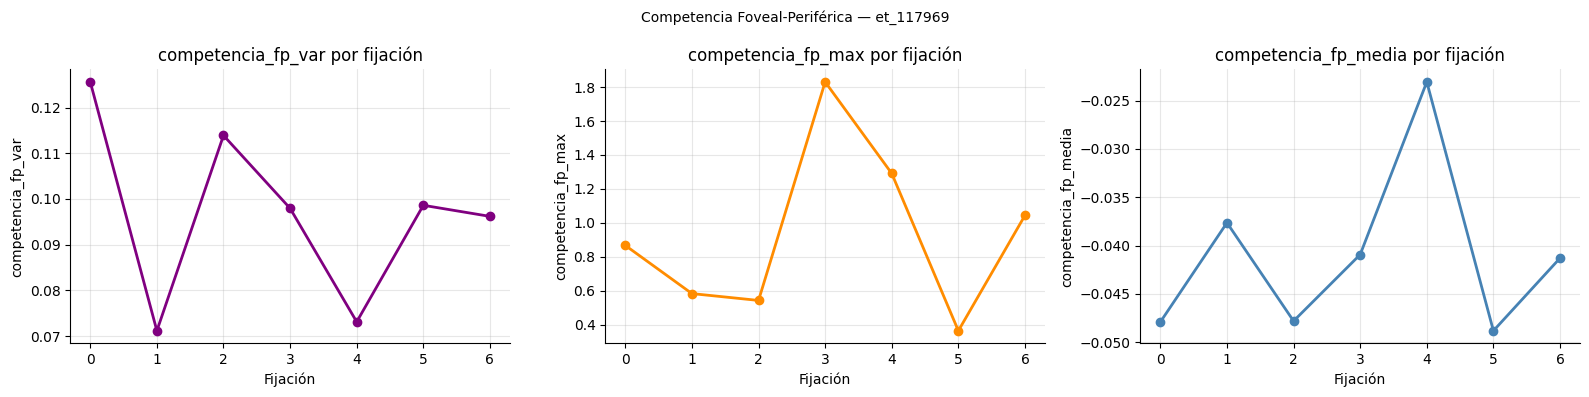

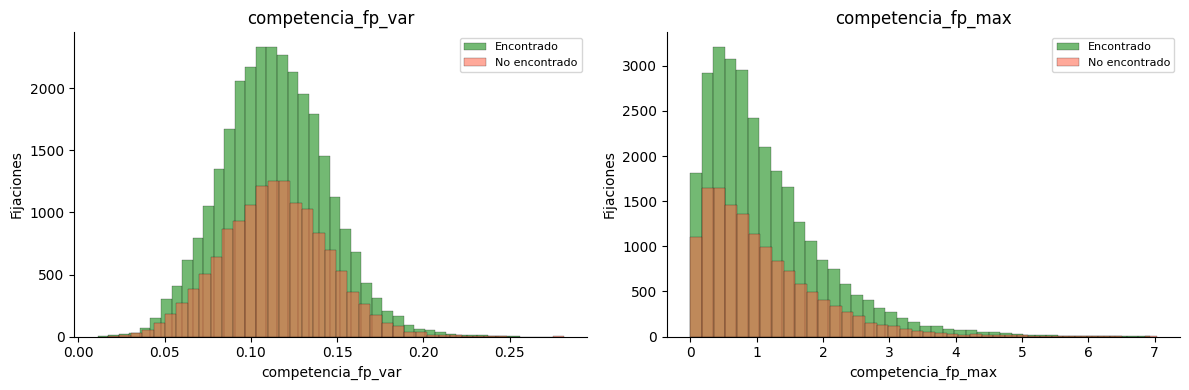

In [9]:
fp_var  = np.array([f['competencia_fp_var']   for f in feats_ej['fijaciones']])
fp_max  = np.array([f['competencia_fp_max']   for f in feats_ej['fijaciones']])
fp_med  = np.array([f['competencia_fp_media'] for f in feats_ej['fijaciones']])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, vals, lbl, col in [
    (axes[0], fp_var,  'competencia_fp_var',   'purple'),
    (axes[1], fp_max,  'competencia_fp_max',   'darkorange'),
    (axes[2], fp_med,  'competencia_fp_media', 'steelblue'),
]:
    ax.plot(range(n_ej), vals, 'o-', color=col, linewidth=2)
    ax.set_xlabel('Fijación'); ax.set_ylabel(lbl)
    ax.set_title(f'{lbl} por fijación'); ax.grid(True, alpha=0.3)

plt.suptitle(f'Competencia Foveal-Periférica — {SUJETO_EJ}', fontsize=10)
plt.tight_layout(); plt.show()

# Distribución agrupada por target_found
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col_name, color_found, color_not in [
    (axes[0], 'competencia_fp_var',  'green', 'tomato'),
    (axes[1], 'competencia_fp_max',  'green', 'tomato'),
]:
    for tf, lbl, col in [(True,'Encontrado',color_found),(False,'No encontrado',color_not)]:
        vals = df[df['target_found']==tf][col_name].dropna()
        ax.hist(vals, bins=40, alpha=0.55, label=lbl, color=col, edgecolor='k', lw=0.3)
    ax.set_xlabel(col_name); ax.set_ylabel('Fijaciones')
    ax.set_title(col_name); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 5. Probabilidad Posterior

**Qué mide:** valor del posterior bayesiano en la celda fijada. Cuánta "creencia"
asigna el modelo a que el target está en el punto que el sujeto fijó.

**Qué esperar:**
- Valores altos cuando el sujeto fija directamente en el target.
- En trials **encontrados**, debería haber al menos una fijación con posterior alto.

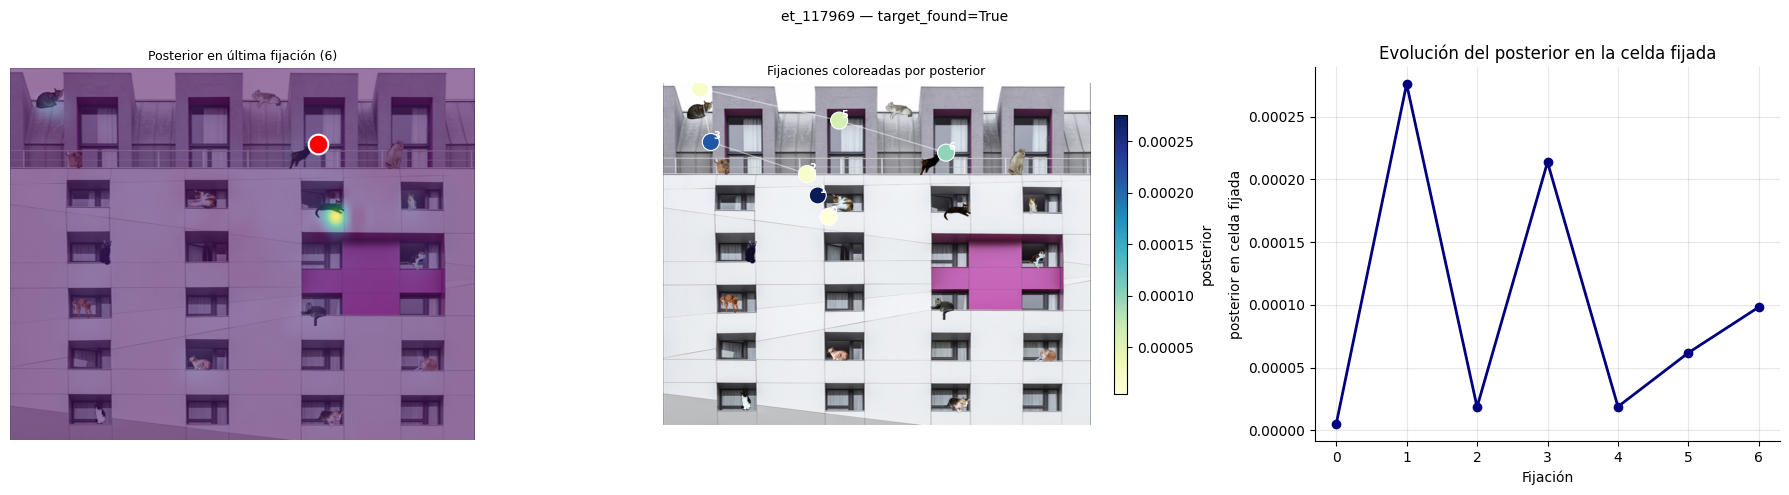

Posterior en celda fijada vs. máximo del mapa:
  Fix 0: en_fijacion=0.00000  max_mapa=0.01940  ratio=0.00
  Fix 1: en_fijacion=0.00028  max_mapa=0.01814  ratio=0.02
  Fix 2: en_fijacion=0.00002  max_mapa=0.01963  ratio=0.00
  Fix 3: en_fijacion=0.00021  max_mapa=0.01065  ratio=0.02
  Fix 4: en_fijacion=0.00002  max_mapa=0.03505  ratio=0.00
  Fix 5: en_fijacion=0.00006  max_mapa=0.01074  ratio=0.01
  Fix 6: en_fijacion=0.00010  max_mapa=0.03754  ratio=0.00


In [10]:
post_vals = np.array([f['posterior'] for f in feats_ej['fijaciones']])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# a) Posterior map en la última fijación (máxima acumulación)
post_last = mapas_ej['posterior'][-1]
superponer_mapa(axes[0], img_ej, post_last, cmap='viridis',
                titulo=f'Posterior en última fijación ({n_ej-1})')
# Marcar posición de la última fijación
axes[0].scatter([xs_ej[-1]], [ys_ej[-1]], s=200, c='red', zorder=6,
                edgecolors='white', linewidths=1.5)

# b) Scanpath coloreado por posterior en fijación
sc = mostrar_fijaciones(axes[1], img_ej, ys_ej, xs_ej,
                         valores=post_vals, cmap='YlGnBu',
                         titulo='Fijaciones coloreadas por posterior')
plt.colorbar(sc, ax=axes[1], fraction=0.03, label='posterior')

# c) Evolución temporal
axes[2].plot(range(n_ej), post_vals, 'o-', color='navy', linewidth=2)
axes[2].set_xlabel('Fijación'); axes[2].set_ylabel('posterior en celda fijada')
axes[2].set_title('Evolución del posterior en la celda fijada')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'{SUJETO_EJ} — target_found={mapas_ej["target_found"]}', fontsize=10)
plt.tight_layout(); plt.show()

# Comparación: posterior máximo del mapa vs. posterior en celda fijada
post_max = ml.concentracion_posterior(mapas_ej)
print('Posterior en celda fijada vs. máximo del mapa:')
for i, (pf, pm) in enumerate(zip(post_vals, post_max)):
    print(f'  Fix {i}: en_fijacion={pf:.5f}  max_mapa={pm:.5f}  ratio={pf/pm:.2f}')

### 6. Entropía del Prior

**Qué mide:** incertidumbre inicial antes de comenzar la búsqueda.
- `entropia_prior_saliencia`: entropía de la distribución de saliencia cruda.
- `entropia_prior_modelo`: entropía del posterior en t=0 (prior real del modelo).

**Qué esperar:**
- **Constante** dentro de cada trial (mismo valor en todas las fijaciones).
- Variable entre imágenes: escenas complejas/uniformes tienen entropía alta;
  imágenes con un foco saliente tienen entropía baja.

entropia_prior_saliencia — único valor en el trial: {5.796697}
entropia_prior_modelo    — único valor en el trial: {6.046572}


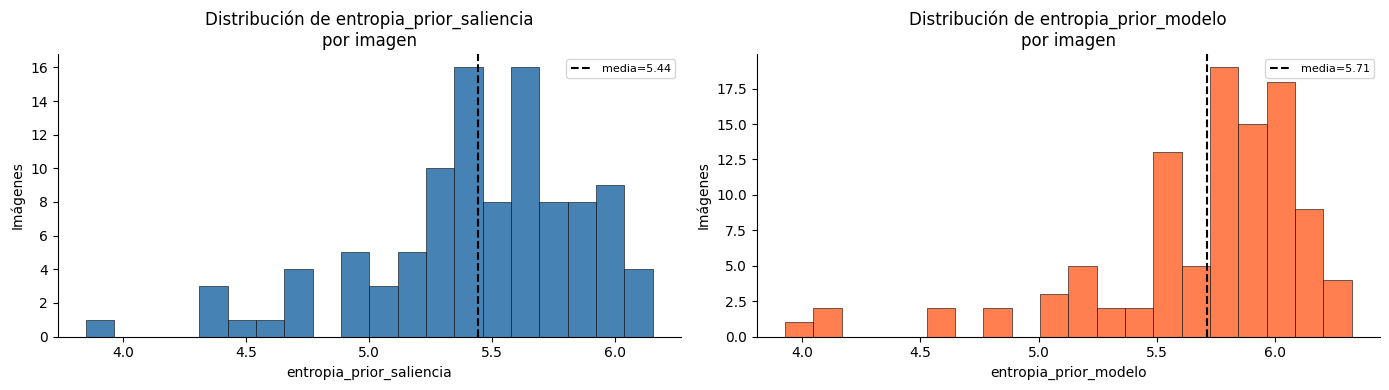

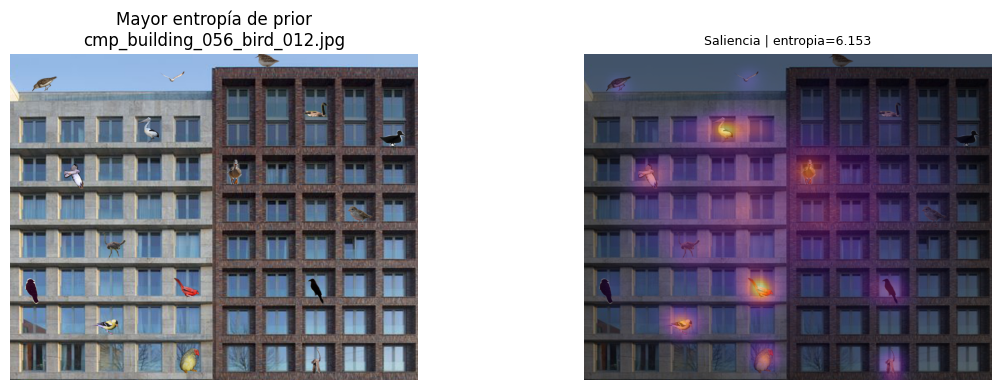

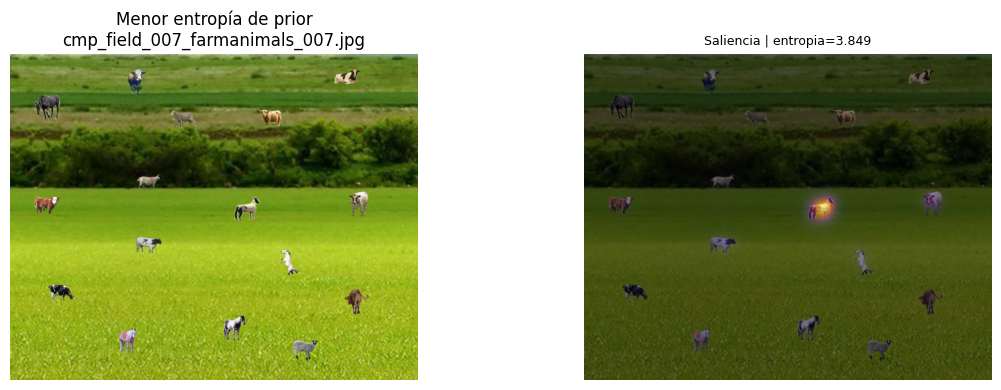

In [11]:
# Verificar que es constante dentro del trial
prior_sal_trial = [f['entropia_prior_saliencia'] for f in feats_ej['fijaciones']]
prior_mod_trial = [f['entropia_prior_modelo']    for f in feats_ej['fijaciones']]
print(f'entropia_prior_saliencia — único valor en el trial: {set(map(lambda x: round(x,6), prior_sal_trial))}')
print(f'entropia_prior_modelo    — único valor en el trial: {set(map(lambda x: round(x,6), prior_mod_trial))}')

# Distribución entre imágenes (una fila por imagen, valor constante)
prior_by_img = (df.groupby('imagen')[['entropia_prior_saliencia','entropia_prior_modelo']]
                  .first().reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, col2 in [
    (axes[0], 'entropia_prior_saliencia', 'steelblue'),
    (axes[1], 'entropia_prior_modelo',    'coral'),
]:
    ax.hist(prior_by_img[col], bins=20, color=col2, edgecolor='k', linewidth=0.4)
    ax.axvline(prior_by_img[col].mean(), color='k', linestyle='--', label=f'media={prior_by_img[col].mean():.2f}')
    ax.set_xlabel(col); ax.set_ylabel('Imágenes'); ax.set_title(f'Distribución de {col}\npor imagen')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Mostrar la imagen con mayor y menor entropía de prior
for lbl, idx_fn in [('Mayor entropía de prior', prior_by_img['entropia_prior_saliencia'].idxmax()),
                     ('Menor entropía de prior', prior_by_img['entropia_prior_saliencia'].idxmin())]:
    img_name = prior_by_img.loc[idx_fn, 'imagen']
    ent_val  = prior_by_img.loc[idx_fn, 'entropia_prior_saliencia']
    img_show = ml.cargar_imagen_original(img_name)
    sal_show = ml.cargar_mapa_saliencia(img_name)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].imshow(img_show); ax[0].set_title(f'{lbl}\n{img_name}'); ax[0].axis('off')
    superponer_mapa(ax[1], img_show, sal_show, cmap='inferno',
                    titulo=f'Saliencia | entropia={ent_val:.3f}')
    plt.tight_layout(); plt.show()

### 7. Entropía Global del Posterior

**Qué mide:** incertidumbre global del modelo en el momento `t`. Es la suma de
`-p·log(p)` sobre todas las celdas del posterior.

**Qué esperar:**
- Debería **decrecer** a medida que el modelo acumula evidencia (la distribución se concentra).
- La reducción debería ser más marcada en trials donde el target **fue encontrado**.

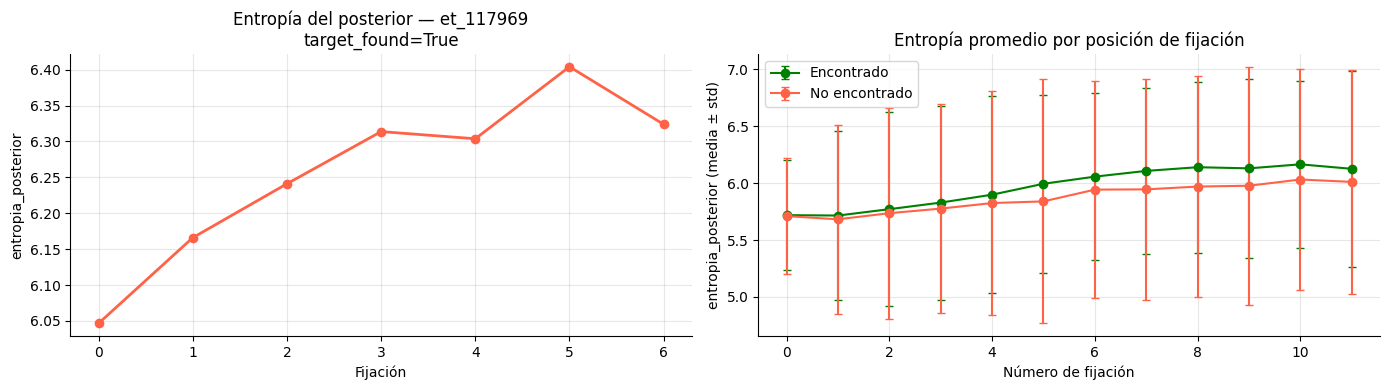

Trials donde entropia_final < entropia_inicial: 1167/4442 (26%)
Reducción media: 0.003


In [12]:
ent_vals = np.array([f['entropia_posterior'] for f in feats_ej['fijaciones']])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# a) Trial de ejemplo
axes[0].plot(range(n_ej), ent_vals, 'o-', color='tomato', linewidth=2)
axes[0].set_xlabel('Fijación'); axes[0].set_ylabel('entropia_posterior')
axes[0].set_title(f'Entropía del posterior — {SUJETO_EJ}\ntarget_found={feats_ej["target_found"]}')
axes[0].grid(True, alpha=0.3)

# b) Curva media por target_found
for tf, lbl, col in [(True,'Encontrado','green'),(False,'No encontrado','tomato')]:
    sub = df[df['target_found']==tf]
    grp = sub[sub['fixation'] < 12].groupby('fixation')['entropia_posterior']
    axes[1].errorbar(grp.mean().index, grp.mean().values, yerr=grp.std().values,
                     fmt='o-', color=col, capsize=3, label=lbl)
axes[1].set_xlabel('Número de fijación'); axes[1].set_ylabel('entropia_posterior (media ± std)')
axes[1].set_title('Entropía promedio por posición de fijación')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Sanity: ¿la entropía final < inicial en la mayoría de los trials?
df_first_last = (df.sort_values('fixation')
                   .groupby(['imagen','sujeto'])
                   .agg(ent_ini=('entropia_posterior','first'),
                        ent_fin=('entropia_posterior','last'))
                   .reset_index())
n_decrece = (df_first_last['ent_fin'] < df_first_last['ent_ini']).sum()
n_tot = len(df_first_last)
print(f'Trials donde entropia_final < entropia_inicial: {n_decrece}/{n_tot} ({100*n_decrece/n_tot:.0f}%)')
print(f'Reducción media: {(df_first_last["ent_ini"] - df_first_last["ent_fin"]).mean():.3f}')

### 8. Ganancia de Información (KL Divergencia)

**Qué mide:** `KL(P_t ∥ P_{t-1})` — cuánta información nueva aportó la fijación `t`
al actualizar la creencia bayesiana. `None` en la primera fijación (sin referencia anterior).

**Qué esperar:**
- Siempre `>= 0` (sanity check fundamental).
- Valores altos en fijaciones muy informativas (cambio grande en la creencia).
- Puede tener picos al inicio del trial cuando el prior es difuso.

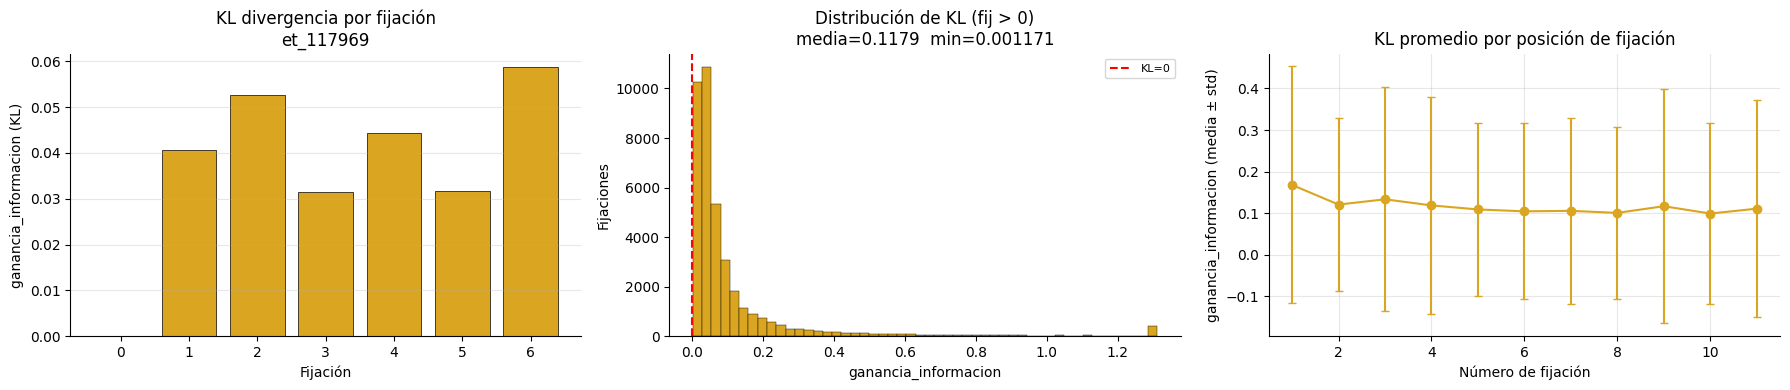

Valores negativos de ganancia_informacion: 0 (esperado: 0)


In [13]:
kl_vals = np.array([f['ganancia_informacion'] if f['ganancia_informacion'] is not None
                    else np.nan for f in feats_ej['fijaciones']])

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# a) Trial de ejemplo
axes[0].bar(range(n_ej), np.nan_to_num(kl_vals), color='goldenrod', edgecolor='k', lw=0.5)
axes[0].set_xlabel('Fijación'); axes[0].set_ylabel('ganancia_informacion (KL)')
axes[0].set_title(f'KL divergencia por fijación\n{SUJETO_EJ}')
axes[0].grid(True, alpha=0.3, axis='y')

# b) Distribución global (excluyendo fijación 0)
kl_all = df[df['fixation'] > 0]['ganancia_informacion'].dropna()
axes[1].hist(kl_all.clip(upper=kl_all.quantile(0.99)), bins=50,
             color='goldenrod', edgecolor='k', lw=0.3)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='KL=0')
axes[1].set_xlabel('ganancia_informacion'); axes[1].set_ylabel('Fijaciones')
axes[1].set_title(f'Distribución de KL (fij > 0)\nmedia={kl_all.mean():.4f}  min={kl_all.min():.6f}')
axes[1].legend(fontsize=8)

# c) Media por posición de fijación
grp = df[df['fixation'].between(1,11)].groupby('fixation')['ganancia_informacion']
axes[2].errorbar(grp.mean().index, grp.mean().values, yerr=grp.std().values,
                 fmt='o-', color='goldenrod', capsize=3)
axes[2].set_xlabel('Número de fijación'); axes[2].set_ylabel('ganancia_informacion (media ± std)')
axes[2].set_title('KL promedio por posición de fijación'); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Sanity: todos los valores deben ser >= 0
n_neg = (kl_all < 0).sum()
print(f'Valores negativos de ganancia_informacion: {n_neg} (esperado: 0)')

### 9. Gap de Entropía con el Óptimo

**Qué mide:** dado el EIG map en la fijación `t` (que indica cuánta información ganaría
cada posible sacada desde `t`), ¿qué tan bien eligió el humano su **próxima** fijación (`t+1`)?

- `eig_optimo`: EIG máximo en el mapa de `t` — la sacada óptima que elegiría el modelo.
- `eig_en_fijacion`: EIG que el humano **obtendrá** yendo a `t+1`, evaluado en el mapa de `t`.
- `gap_entropia = eig_optimo - eig_en_fijacion`: cuán subóptima fue la sacada humana.
- `None` en la última fijación (no existe `t+1`).

**Qué esperar:**
- `gap_entropia >= 0` siempre (**sanity check**): el óptimo es al menos tan bueno como la elección humana.
- Gap cercano a 0 → sacada casi óptima; gap alto → el humano fue a una región poco informativa.
- La última fijación de cada trial es `None` (no tiene sacada siguiente).

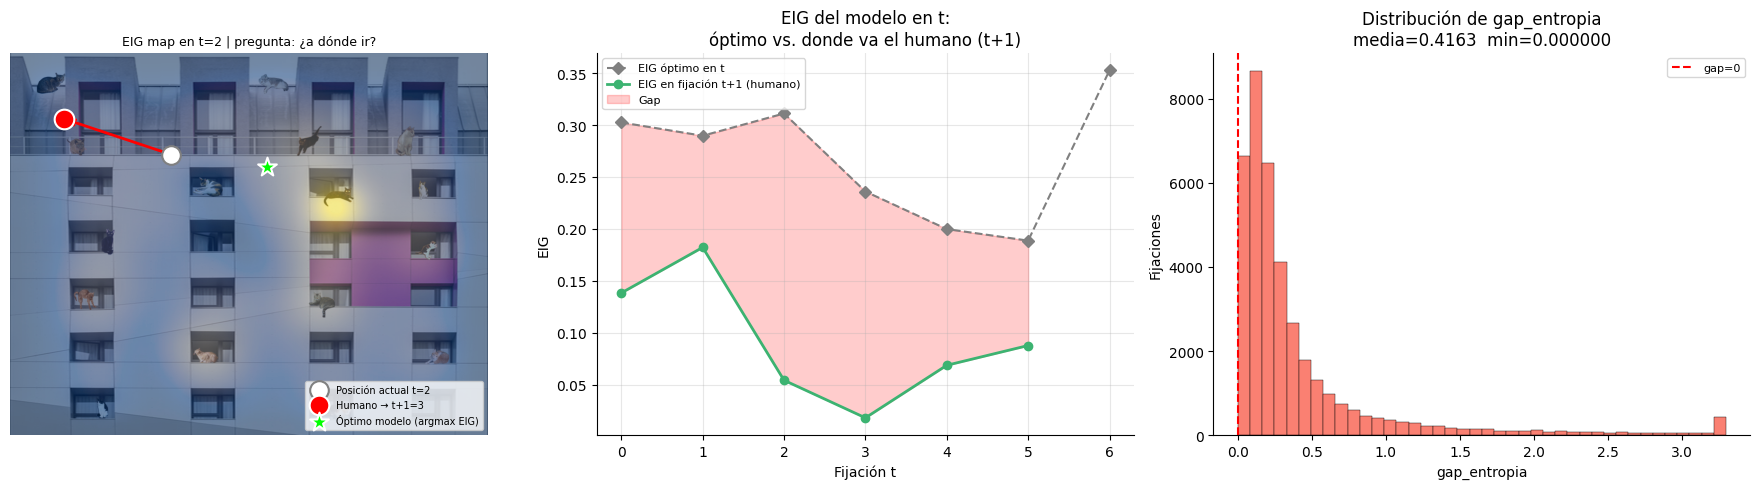

Valores negativos de gap_entropia : 0 (esperado: 0)
Fijaciones con gap=None (última fijación por trial): 4442


In [14]:
# eig_en_fijacion: EIG en la posición t+1 del humano, evaluado en el mapa de t
# None en la última fijación de cada trial
eig_fix  = np.array([f['eig_en_fijacion'] if f['eig_en_fijacion'] is not None else np.nan
                     for f in feats_ej['fijaciones']])
eig_opt  = np.array([f['eig_optimo'] for f in feats_ej['fijaciones']])
gap_vals = np.array([f['gap_entropia'] if f['gap_entropia'] is not None else np.nan
                     for f in feats_ej['fijaciones']])

# Paso intermedio para la visualización del EIG map
step = min(2, n_ej - 2)
eig_map_t = mapas_ej['expected_ig_map'][step]
opt_y_g, opt_x_g = np.unravel_index(eig_map_t.argmax(), eig_map_t.shape)
opt_y_px = opt_y_g * CELL_SIZE + CELL_SIZE // 2
opt_x_px = opt_x_g * CELL_SIZE + CELL_SIZE // 2
curr_y_px, curr_x_px = ys_ej[step],   xs_ej[step]
next_y_px, next_x_px = ys_ej[step+1], xs_ej[step+1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# a) EIG map en t: posición actual (blanca), próxima fijación humana (roja), óptimo modelo (verde)
superponer_mapa(axes[0], img_ej, eig_map_t, cmap='cividis',
                titulo=f'EIG map en t={step} | pregunta: ¿a dónde ir?')
axes[0].scatter([curr_x_px], [curr_y_px], s=180, c='white', zorder=6,
                edgecolors='gray',  lw=1.5, marker='o', label=f'Posición actual t={step}')
axes[0].scatter([next_x_px], [next_y_px], s=200, c='red',   zorder=7,
                edgecolors='white', lw=1.5, marker='o', label=f'Humano → t+1={step+1}')
axes[0].scatter([opt_x_px],  [opt_y_px],  s=200, c='lime',  zorder=7,
                edgecolors='white', lw=1.5, marker='*', label='Óptimo modelo (argmax EIG)')
axes[0].annotate('', xy=(next_x_px, next_y_px), xytext=(curr_x_px, curr_y_px),
                 arrowprops=dict(arrowstyle='->', color='red', lw=2))
axes[0].legend(loc='lower right', fontsize=7)

# b) EIG en t+1 (humano) vs. EIG óptimo en t — la última fijación queda vacía
valid_idx = np.where(~np.isnan(eig_fix))[0]
axes[1].plot(range(n_ej), eig_opt, 'D--', color='gray',          linewidth=1.5, label='EIG óptimo en t')
axes[1].plot(valid_idx,   eig_fix[valid_idx], 'o-', color='mediumseagreen', linewidth=2,
             label='EIG en fijación t+1 (humano)')
axes[1].fill_between(valid_idx, eig_fix[valid_idx], eig_opt[valid_idx],
                     alpha=0.2, color='red', label='Gap')
axes[1].set_xlabel('Fijación t'); axes[1].set_ylabel('EIG')
axes[1].set_title('EIG del modelo en t:\nóptimo vs. donde va el humano (t+1)')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

# c) Distribución global del gap
gap_all = df['gap_entropia'].dropna()
axes[2].hist(gap_all.clip(upper=gap_all.quantile(0.99)), bins=40,
             color='salmon', edgecolor='k', lw=0.3)
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5, label='gap=0')
axes[2].set_xlabel('gap_entropia'); axes[2].set_ylabel('Fijaciones')
axes[2].set_title(f'Distribución de gap_entropia\nmedia={gap_all.mean():.4f}  min={gap_all.min():.6f}')
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

n_neg_gap = (gap_all < -1e-8).sum()
print(f'Valores negativos de gap_entropia : {n_neg_gap} (esperado: 0)')
print(f'Fijaciones con gap=None (última fijación por trial): {df["gap_entropia"].isna().sum()}')

### 10. Distancia con la Decisión del Modelo

**Qué mide:** dado el EIG map en la fijación `t`, ¿cuán lejos está la sacada del humano
(hacia `t+1`) del argmax que elegiría el modelo?

- `modelo_fix_y`, `modelo_fix_x`: celda óptima del modelo en `t` (argmax del EIG map).
- `distancia_grilla`: distancia euclidiana entre `(y_{t+1}, x_{t+1})` y el argmax en `t`.
- `distancia_pixels = distancia_grilla × 32`.
- `None` en la última fijación (no existe `t+1`).

**Qué esperar:**
- Distancias pequeñas = humano y modelo eligieron sacadas similares.
- Complementa el gap: el gap mide diferencia en EIG, la distancia mide diferencia espacial.

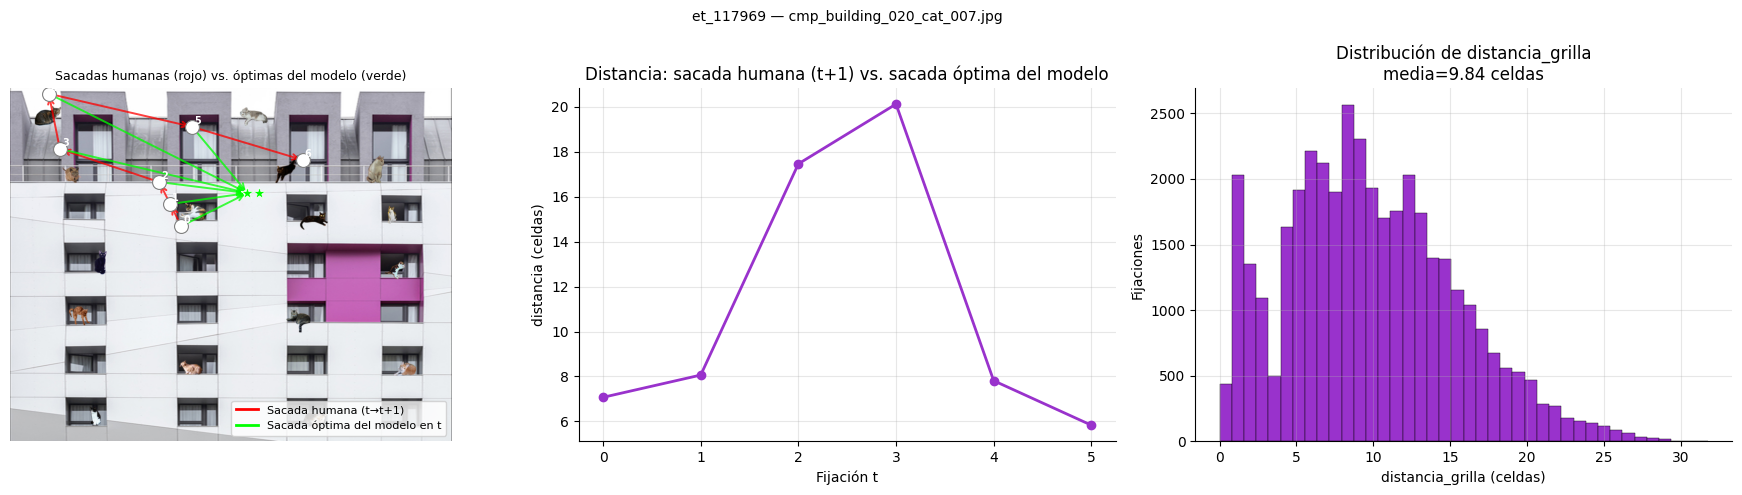

Distancia media (Encontrado): 9.61 celdas = 308 px
Distancia media (No encontrado): 10.29 celdas = 329 px
Fijaciones con distancia=None (última fijación por trial): 4442


In [15]:
# distancia_grilla: distancia desde la fijación t+1 del humano al argmax del EIG map en t
# None en la última fijación
dist_vals = np.array([f['distancia_grilla'] if f['distancia_grilla'] is not None else np.nan
                      for f in feats_ej['fijaciones']])
mod_ys_g  = np.array([f['modelo_fix_y'] for f in feats_ej['fijaciones']])
mod_xs_g  = np.array([f['modelo_fix_x'] for f in feats_ej['fijaciones']])
mod_ys_px = mod_ys_g * CELL_SIZE + CELL_SIZE // 2
mod_xs_px = mod_xs_g * CELL_SIZE + CELL_SIZE // 2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# a) Imagen: flechas de sacada humana (t→t+1) en rojo y sacada óptima del modelo en verde
axes[0].imshow(img_ej)
for i in range(n_ej - 1):  # sin flecha en la última fijación
    axes[0].annotate('', xy=(xs_ej[i+1], ys_ej[i+1]), xytext=(xs_ej[i], ys_ej[i]),
                     arrowprops=dict(arrowstyle='->', color='red',  lw=1.4, alpha=0.75))
    axes[0].annotate('', xy=(mod_xs_px[i], mod_ys_px[i]), xytext=(xs_ej[i], ys_ej[i]),
                     arrowprops=dict(arrowstyle='->', color='lime', lw=1.4, alpha=0.75))
axes[0].scatter(xs_ej, ys_ej, s=100, c='white', zorder=5, edgecolors='gray', lw=0.8)
for i in range(n_ej):
    axes[0].text(xs_ej[i]+6, ys_ej[i]-8, str(i), fontsize=7,
                 color='white', zorder=6, fontweight='bold')
axes[0].scatter(mod_xs_px, mod_ys_px, s=80, marker='*', c='lime', zorder=5,
                edgecolors='white', lw=0.5)
axes[0].legend(
    [plt.Line2D([0],[0], color='red',  lw=2),
     plt.Line2D([0],[0], color='lime', lw=2)],
    ['Sacada humana (t→t+1)', 'Sacada óptima del modelo en t'],
    loc='lower right', fontsize=8)
axes[0].axis('off')
axes[0].set_title('Sacadas humanas (rojo) vs. óptimas del modelo (verde)', fontsize=9)

# b) Distancia por fijación (NaN en la última)
valid_idx = np.where(~np.isnan(dist_vals))[0]
axes[1].plot(valid_idx, dist_vals[valid_idx], 'o-', color='darkorchid', linewidth=2)
axes[1].set_xlabel('Fijación t'); axes[1].set_ylabel('distancia (celdas)')
axes[1].set_title('Distancia: sacada humana (t+1) vs. sacada óptima del modelo')
axes[1].grid(True, alpha=0.3)

# c) Distribución global (excluyendo últimas fijaciones)
dist_all = df['distancia_grilla'].dropna()
axes[2].hist(dist_all, bins=40, color='darkorchid', edgecolor='k', lw=0.3)
axes[2].set_xlabel('distancia_grilla (celdas)'); axes[2].set_ylabel('Fijaciones')
axes[2].set_title(f'Distribución de distancia_grilla\nmedia={dist_all.mean():.2f} celdas')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'{SUJETO_EJ} — {IMAGEN_EJ}', fontsize=10)
plt.tight_layout(); plt.show()

for tf, lbl in [(True,'Encontrado'),(False,'No encontrado')]:
    m = df[df['target_found']==tf]['distancia_grilla'].mean()
    print(f'Distancia media ({lbl}): {m:.2f} celdas = {m*32:.0f} px')
print(f'Fijaciones con distancia=None (última fijación por trial): {df["distancia_grilla"].isna().sum()}')

### 11–12. Competencia en el Mapa de EIG

**11. Ratio:** `segundo_mayor / mayor` del EIG map. Cercano a 1 = mucha competencia entre candidatos.

**12. Densidad:** cantidad de celdas dentro del 5% del máximo. Muchas celdas = paisaje de EIG plano.

**Qué esperar:**
- Alta competencia (ratio alto / densidad alta) al inicio del trial cuando el modelo no tiene
  preferencia clara.
- Baja competencia cuando el modelo ha concentrado la atención en un candidato fuerte.

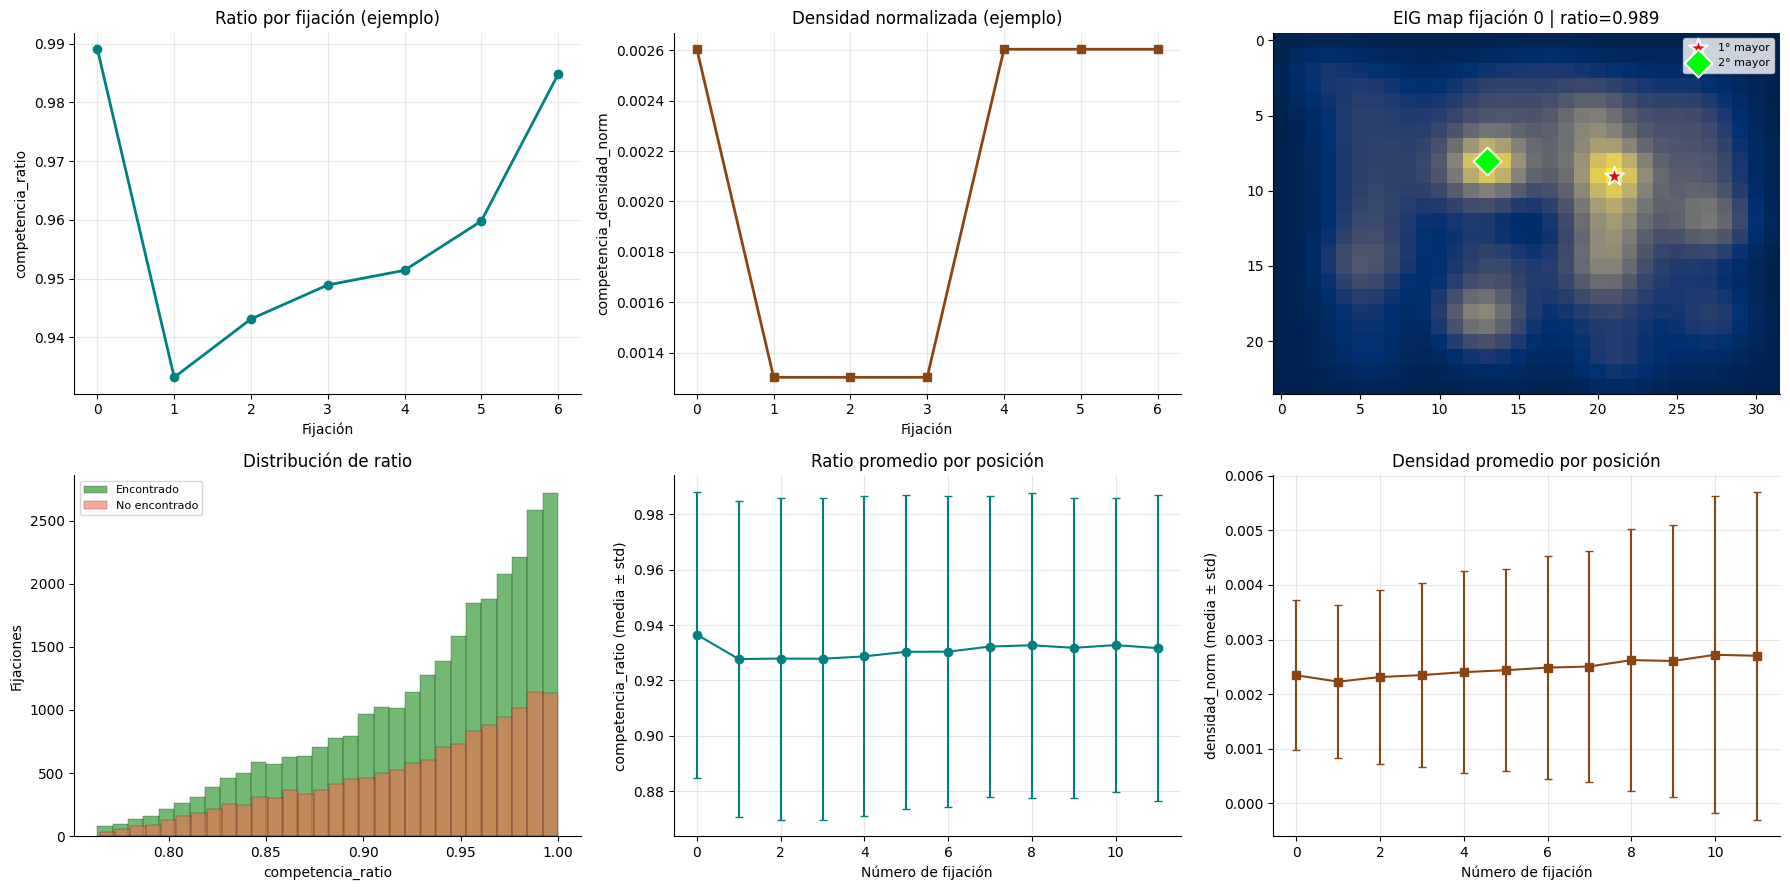

In [16]:
ratio_vals = np.array([f['competencia_ratio']         for f in feats_ej['fijaciones']])
dens_vals  = np.array([f['competencia_densidad_norm'] for f in feats_ej['fijaciones']])

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# Fila superior: trial de ejemplo
axes[0,0].plot(range(n_ej), ratio_vals, 'o-', color='teal', linewidth=2)
axes[0,0].set_xlabel('Fijación'); axes[0,0].set_ylabel('competencia_ratio')
axes[0,0].set_title('Ratio por fijación (ejemplo)'); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(range(n_ej), dens_vals, 's-', color='saddlebrown', linewidth=2)
axes[0,1].set_xlabel('Fijación'); axes[0,1].set_ylabel('competencia_densidad_norm')
axes[0,1].set_title('Densidad normalizada (ejemplo)'); axes[0,1].grid(True, alpha=0.3)

# EIG map con top-2 marcados (primera fijación del ejemplo)
eig_map_0 = mapas_ej['expected_ig_map'][0]
flat = eig_map_0.flatten()
top2_idx = np.argpartition(flat, -2)[-2:]
top2_coords = [np.unravel_index(i, eig_map_0.shape) for i in top2_idx]
axes[0,2].imshow(eig_map_0, cmap='cividis', aspect='auto')
for rank, (cy, cx) in enumerate(sorted(top2_coords, key=lambda c: eig_map_0[c], reverse=True)):
    axes[0,2].scatter([cx], [cy], s=200, c=['red','lime'][rank], zorder=5,
                      edgecolors='white', lw=1.5, marker=['*','D'][rank],
                      label=f'{"1°" if rank==0 else "2°"} mayor')
axes[0,2].set_title(f'EIG map fijación 0 | ratio={ratio_vals[0]:.3f}')
axes[0,2].legend(fontsize=8)

# Fila inferior: distribuciones globales
for tf, lbl, col in [(True,'Encontrado','green'),(False,'No encontrado','tomato')]:
    r = df[df['target_found']==tf]['competencia_ratio'].dropna()
    axes[1,0].hist(r, bins=30, alpha=0.55, label=lbl, color=col, edgecolor='k', lw=0.3)
axes[1,0].set_xlabel('competencia_ratio'); axes[1,0].set_ylabel('Fijaciones')
axes[1,0].set_title('Distribución de ratio'); axes[1,0].legend(fontsize=8)

grp_r = df[df['fixation']<12].groupby('fixation')['competencia_ratio']
axes[1,1].errorbar(grp_r.mean().index, grp_r.mean().values, yerr=grp_r.std().values,
                   fmt='o-', color='teal', capsize=3)
axes[1,1].set_xlabel('Número de fijación'); axes[1,1].set_ylabel('competencia_ratio (media ± std)')
axes[1,1].set_title('Ratio promedio por posición'); axes[1,1].grid(True, alpha=0.3)

grp_d = df[df['fixation']<12].groupby('fixation')['competencia_densidad_norm']
axes[1,2].errorbar(grp_d.mean().index, grp_d.mean().values, yerr=grp_d.std().values,
                   fmt='s-', color='saddlebrown', capsize=3)
axes[1,2].set_xlabel('Número de fijación'); axes[1,2].set_ylabel('densidad_norm (media ± std)')
axes[1,2].set_title('Densidad promedio por posición'); axes[1,2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
## Sección 2: Relación entre Features

### Qué se analiza
1. **Matriz de correlación** — colinealidad pairwise entre todas las features.
2. **Pairplots de features clave** — relaciones no lineales entre pares relevantes para EEG.
3. **Factor de Inflación de Varianza (VIF)** — multicolinealidad en el conjunto completo.
4. **Comparación target_found** — qué features discriminan entre trials exitosos y fallidos.
5. **Perfiles temporales** — cómo covolucionan las features a lo largo del scanpath.

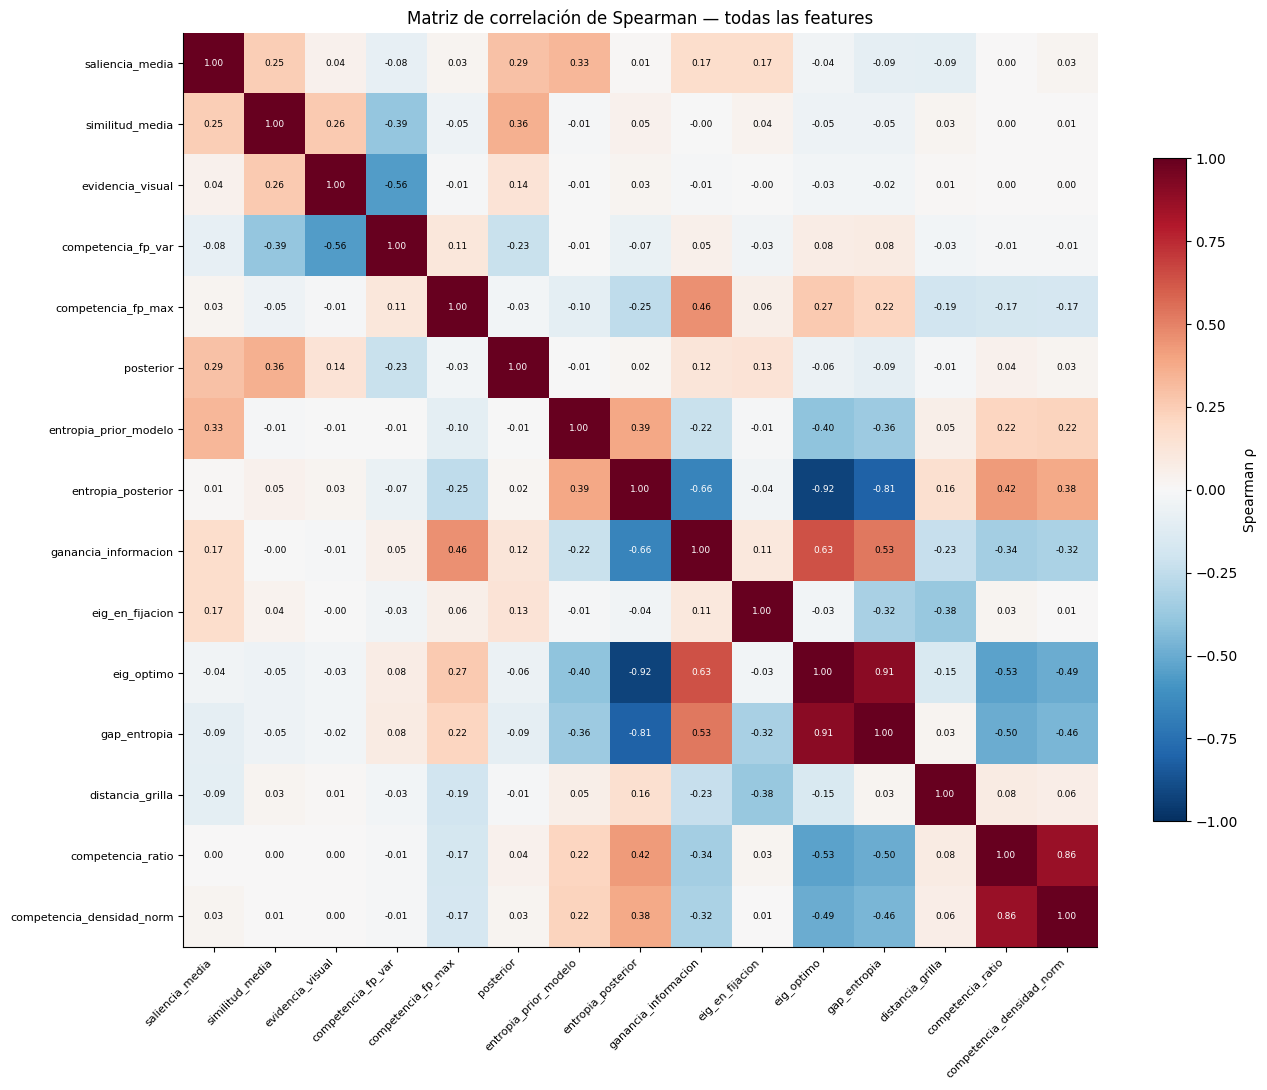

Pares con |ρ| > 0.7 (candidatos a colinealidad):
  entropia_posterior                  × eig_optimo                           ρ = -0.922
  eig_optimo                          × gap_entropia                         ρ = +0.906
  competencia_ratio                   × competencia_densidad_norm            ρ = +0.860
  entropia_posterior                  × gap_entropia                         ρ = -0.807


In [17]:
# ── 2.1 Matriz de correlación ────────────────────────────────────────────────
feat_for_corr = [
    'saliencia_media', 'similitud_media', 'evidencia_visual',
    'competencia_fp_var', 'competencia_fp_max',
    'posterior', 'entropia_prior_modelo', 'entropia_posterior',
    'ganancia_informacion', 'eig_en_fijacion', 'eig_optimo', 'gap_entropia',
    'distancia_grilla', 'competencia_ratio', 'competencia_densidad_norm',
]
df_corr = df[feat_for_corr].dropna()
corr = df_corr.corr(method='spearman')  # Spearman para robustez a outliers

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.03, label='Spearman ρ')
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i, j]
        color = 'white' if abs(v) > 0.6 else 'black'
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6.5, color=color)
ax.set_title('Matriz de correlación de Spearman — todas las features', fontsize=12)
plt.tight_layout(); plt.show()

# Pares con correlación > 0.7 (potencialmente colineales)
high_corr = [(corr.columns[i], corr.columns[j], corr.values[i,j])
             for i in range(len(corr)) for j in range(i+1, len(corr))
             if abs(corr.values[i,j]) > 0.7]
print('Pares con |ρ| > 0.7 (candidatos a colinealidad):')
for f1, f2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f'  {f1:35s} × {f2:35s}  ρ = {r:+.3f}')

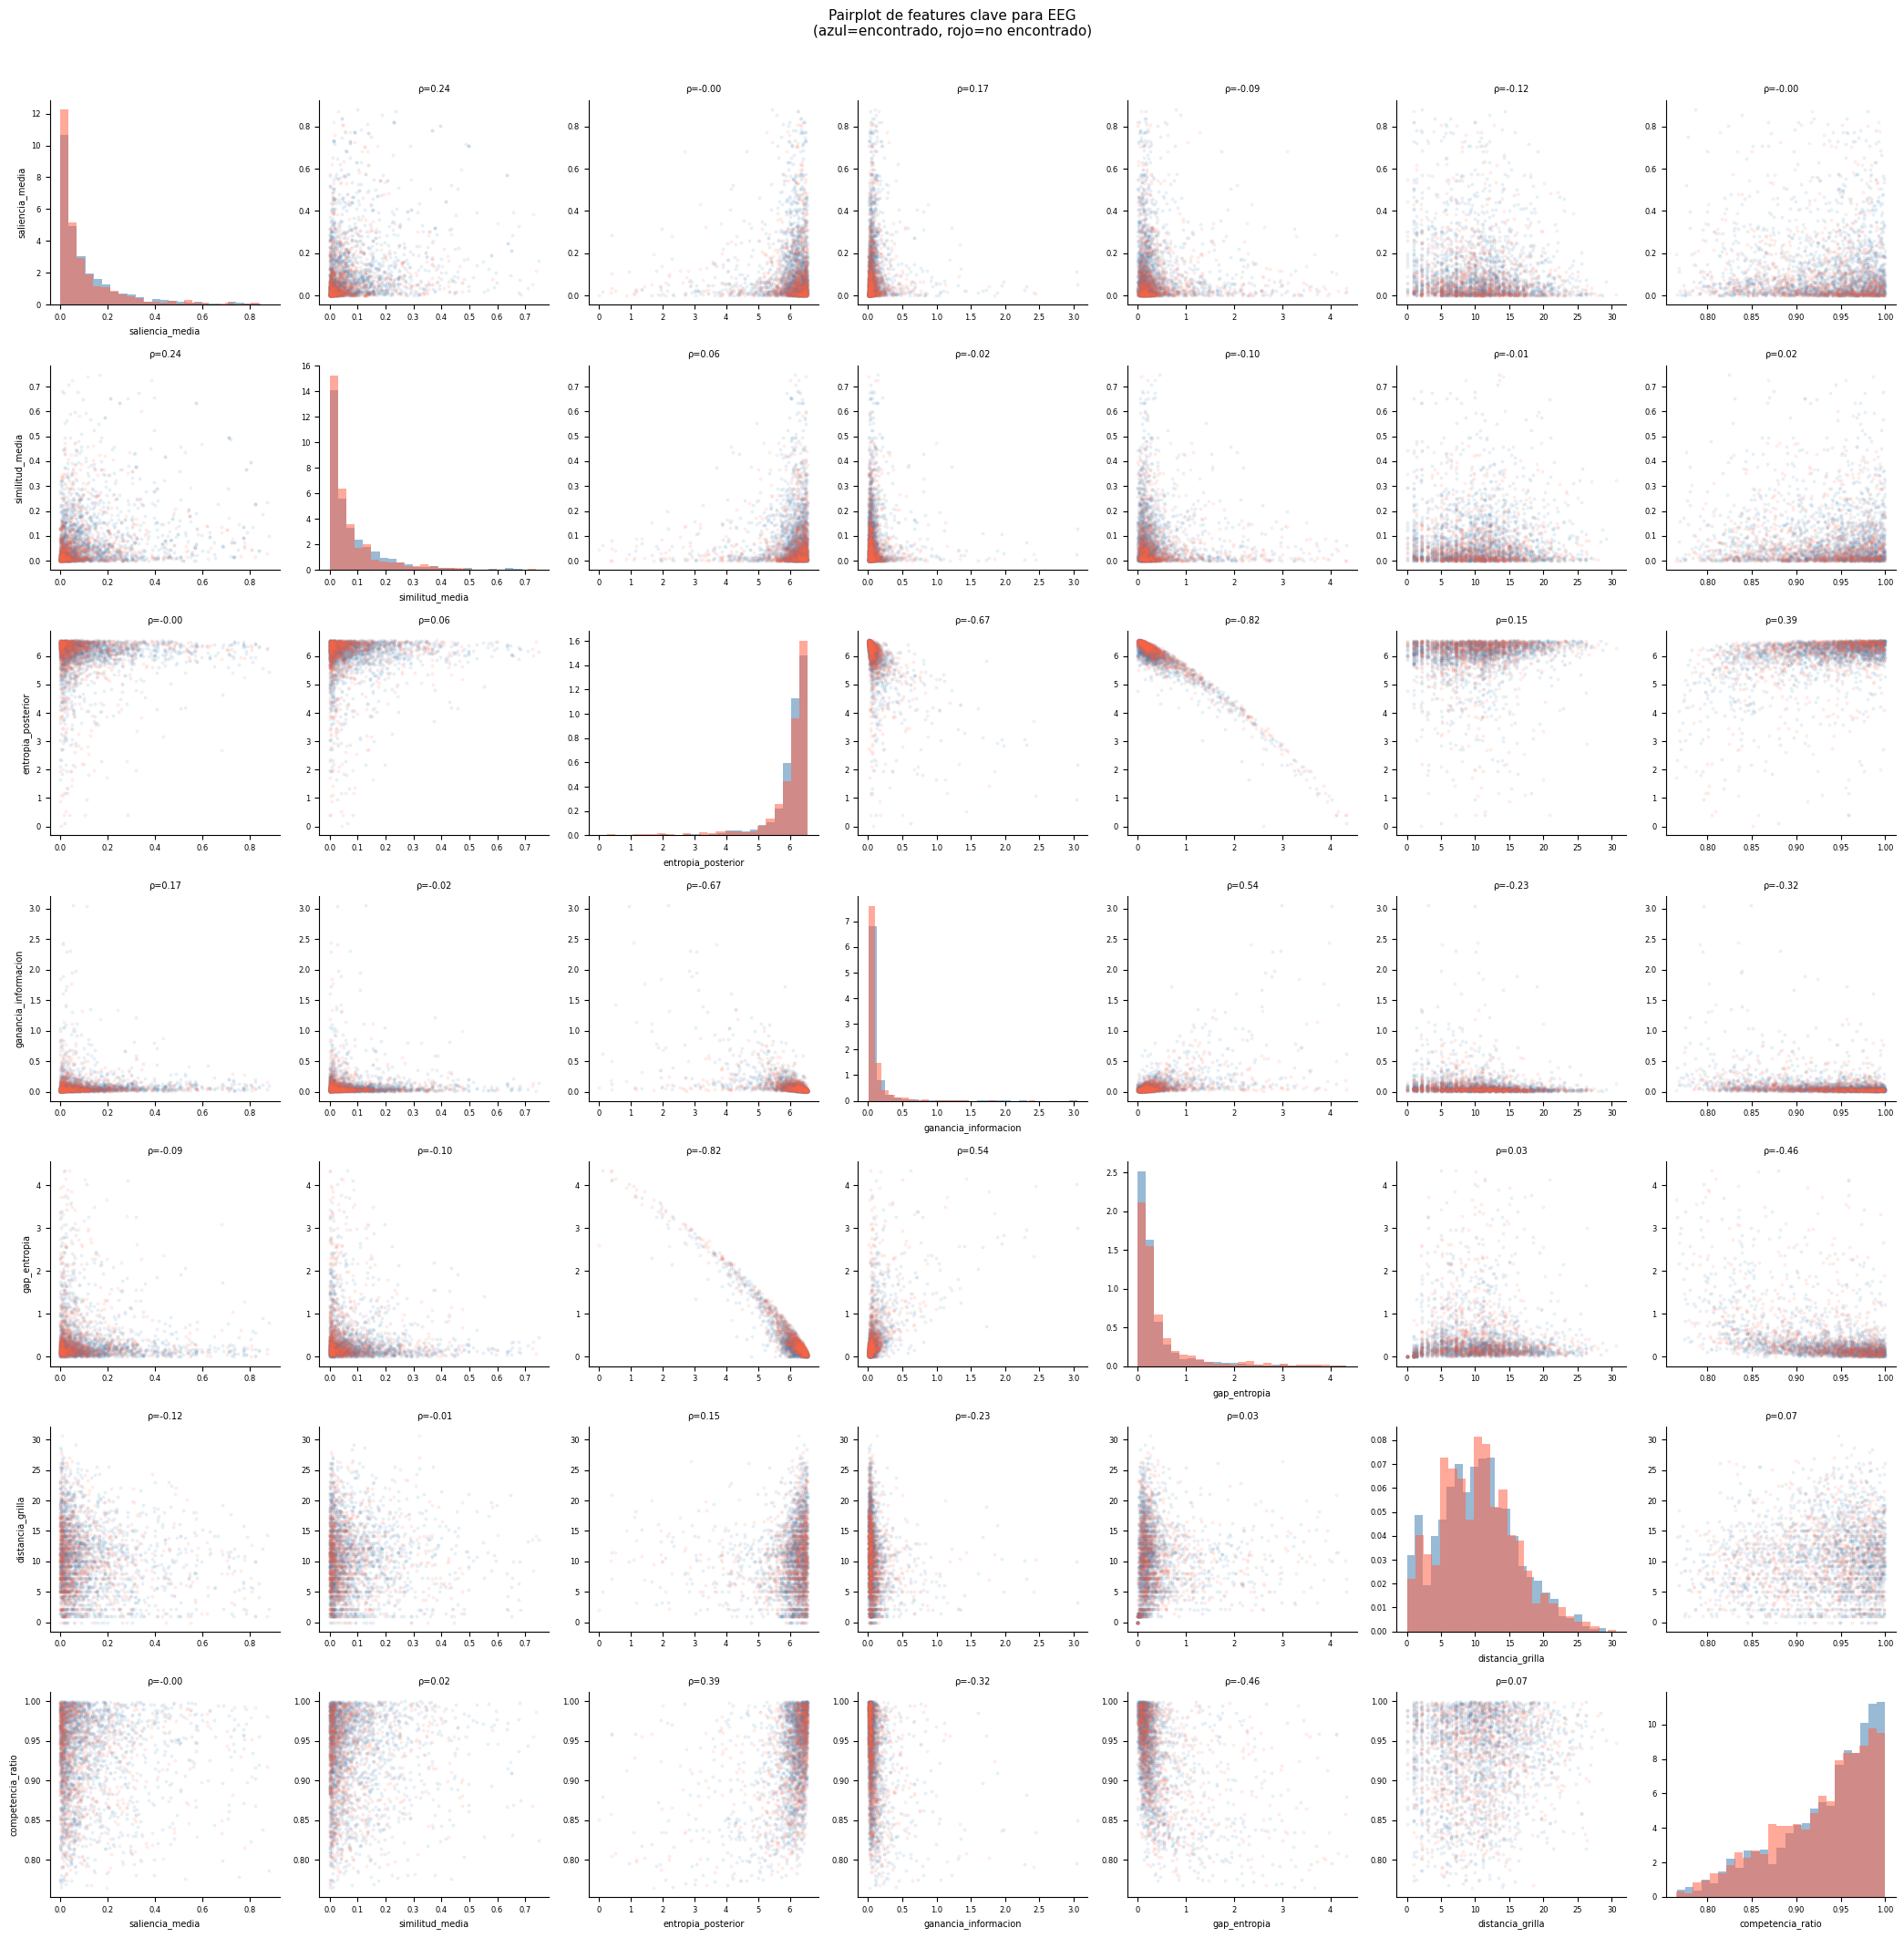

In [18]:
# ── 2.2 Pairplots de features clave para EEG ─────────────────────────────────
# Features teóricamente relevantes para EEG y sin alta colinealidad
feats_eeg = ['saliencia_media', 'similitud_media', 'entropia_posterior',
             'ganancia_informacion', 'gap_entropia', 'distancia_grilla',
             'competencia_ratio']

sample_df = df[feats_eeg + ['target_found']].dropna().sample(
    min(3000, len(df)), random_state=42)

n = len(feats_eeg)
fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n))

colors = {True: 'steelblue', False: 'tomato'}
for i, f1 in enumerate(feats_eeg):
    for j, f2 in enumerate(feats_eeg):
        ax = axes[i, j]
        if i == j:
            for tf, col in colors.items():
                sub = sample_df[sample_df['target_found']==tf][f1]
                ax.hist(sub, bins=25, alpha=0.55, color=col, density=True)
            ax.set_xlabel(f1, fontsize=7)
        else:
            for tf, col in colors.items():
                sub = sample_df[sample_df['target_found']==tf]
                ax.scatter(sub[f2], sub[f1], alpha=0.08, s=4, c=col)
            r, _ = stats.spearmanr(sample_df[f2], sample_df[f1])
            ax.set_title(f'ρ={r:.2f}', fontsize=7)
        if j == 0: ax.set_ylabel(f1, fontsize=7)
        if i == n-1: ax.set_xlabel(f2, fontsize=7)
        ax.tick_params(labelsize=6)

plt.suptitle('Pairplot de features clave para EEG\n(azul=encontrado, rojo=no encontrado)',
             fontsize=11, y=1.01)
plt.tight_layout(); plt.show()

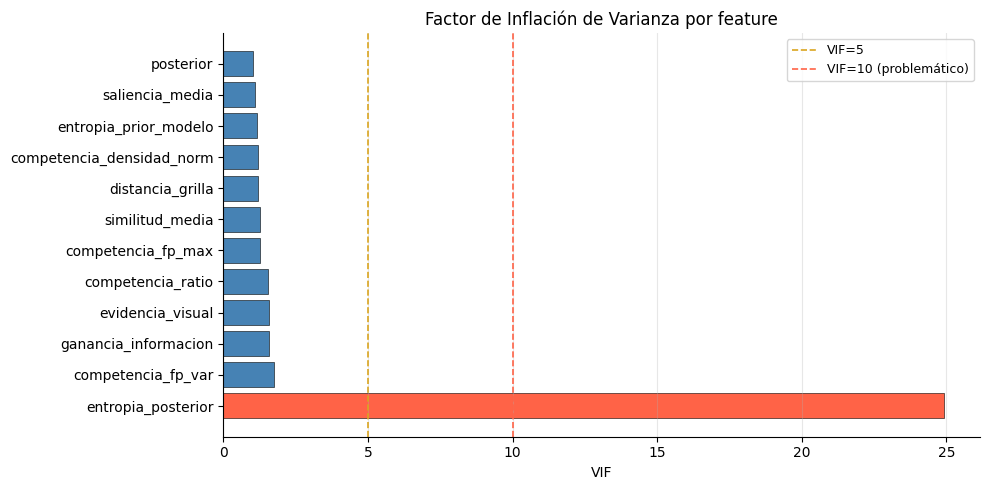

                  Feature       VIF
          eig_en_fijacion       inf
               eig_optimo       inf
             gap_entropia       inf
       entropia_posterior 24.916043
       competencia_fp_var  1.744740
     ganancia_informacion  1.590071
         evidencia_visual  1.564155
        competencia_ratio  1.547109
       competencia_fp_max  1.271285
          similitud_media  1.257723
         distancia_grilla  1.213288
competencia_densidad_norm  1.203742
    entropia_prior_modelo  1.174486
          saliencia_media  1.101688
                posterior  1.041327


In [19]:
# ── 2.3 VIF — Factor de Inflación de Varianza ─────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_vif = df[feat_for_corr].dropna().sample(min(5000, len(df)), random_state=42)
# Estandarizar para VIF
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(df_vif)

vif_data = pd.DataFrame({
    'Feature': feat_for_corr,
    'VIF': [variance_inflation_factor(X, i) for i in range(X.shape[1])]
}).sort_values('VIF', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_vif = ['tomato' if v > 10 else 'goldenrod' if v > 5 else 'steelblue'
              for v in vif_data['VIF']]
ax.barh(vif_data['Feature'], vif_data['VIF'], color=colors_vif, edgecolor='k', lw=0.4)
ax.axvline(5,  color='goldenrod', linestyle='--', linewidth=1.2, label='VIF=5')
ax.axvline(10, color='tomato',    linestyle='--', linewidth=1.2, label='VIF=10 (problemático)')
ax.set_xlabel('VIF'); ax.set_title('Factor de Inflación de Varianza por feature')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

print(vif_data.to_string(index=False))

,feature,media_found,media_notfound,U,p,r,signif
9,eig_en_fijacion,0.1056,0.0867,191231018.0,0.0000,-0.1425,***
5,posterior,0.0003,0.0002,221849138.0,0.0000,-0.0876,***
7,entropia_posterior,5.9368,5.9161,186569548.0,0.0000,0.0853,***
11,gap_entropia,0.3802,0.4867,154797134.0,0.0000,0.0752,***
0,saliencia_media,0.1149,0.1012,217178595.0,0.0000,-0.0647,***
12,distancia_grilla,9.6147,10.2872,156211148.5,0.0000,0.0667,***
8,ganancia_informacion,0.1193,0.1151,177156860.0,0.0000,-0.0584,***
6,entropia_prior_modelo,5.7395,5.6940,214328148.5,0.0000,-0.0508,***
1,similitud_media,0.0806,0.0729,213642320.0,0.0000,-0.0474,***
14,competencia_densidad_norm,0.0025,0.0024,212533024.5,0.0000,-0.0420,***


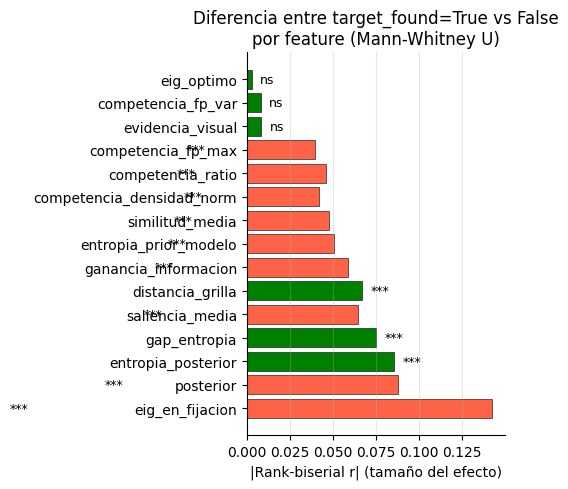

In [20]:
# ── 2.4 Comparación target_found — efecto por feature ─────────────────────────
from scipy.stats import mannwhitneyu

comparaciones = []
for feat in feat_for_corr:
    g1 = df[df['target_found']==True][feat].dropna()
    g2 = df[df['target_found']==False][feat].dropna()
    if len(g1) < 10 or len(g2) < 10:
        continue
    u, p = mannwhitneyu(g1, g2, alternative='two-sided')
    # Effect size: rank-biserial correlation
    n1, n2 = len(g1), len(g2)
    r = 1 - 2*u/(n1*n2)
    comparaciones.append({'feature': feat, 'media_found': g1.mean(),
                           'media_notfound': g2.mean(), 'U': u, 'p': p, 'r': r})

comp_df = pd.DataFrame(comparaciones).sort_values('p')
comp_df['signif'] = comp_df['p'].apply(lambda p: '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns')
display(comp_df.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
colors_r = ['green' if r > 0 else 'tomato' for r in comp_df['r']]
ax.barh(comp_df['feature'], comp_df['r'].abs(), color=colors_r, edgecolor='k', lw=0.4)
for i, (_, row) in enumerate(comp_df.iterrows()):
    ax.text(row['r'].real + 0.005, i, row['signif'], va='center', fontsize=9)
ax.set_xlabel('|Rank-biserial r| (tamaño del efecto)')
ax.set_title('Diferencia entre target_found=True vs False\npor feature (Mann-Whitney U)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

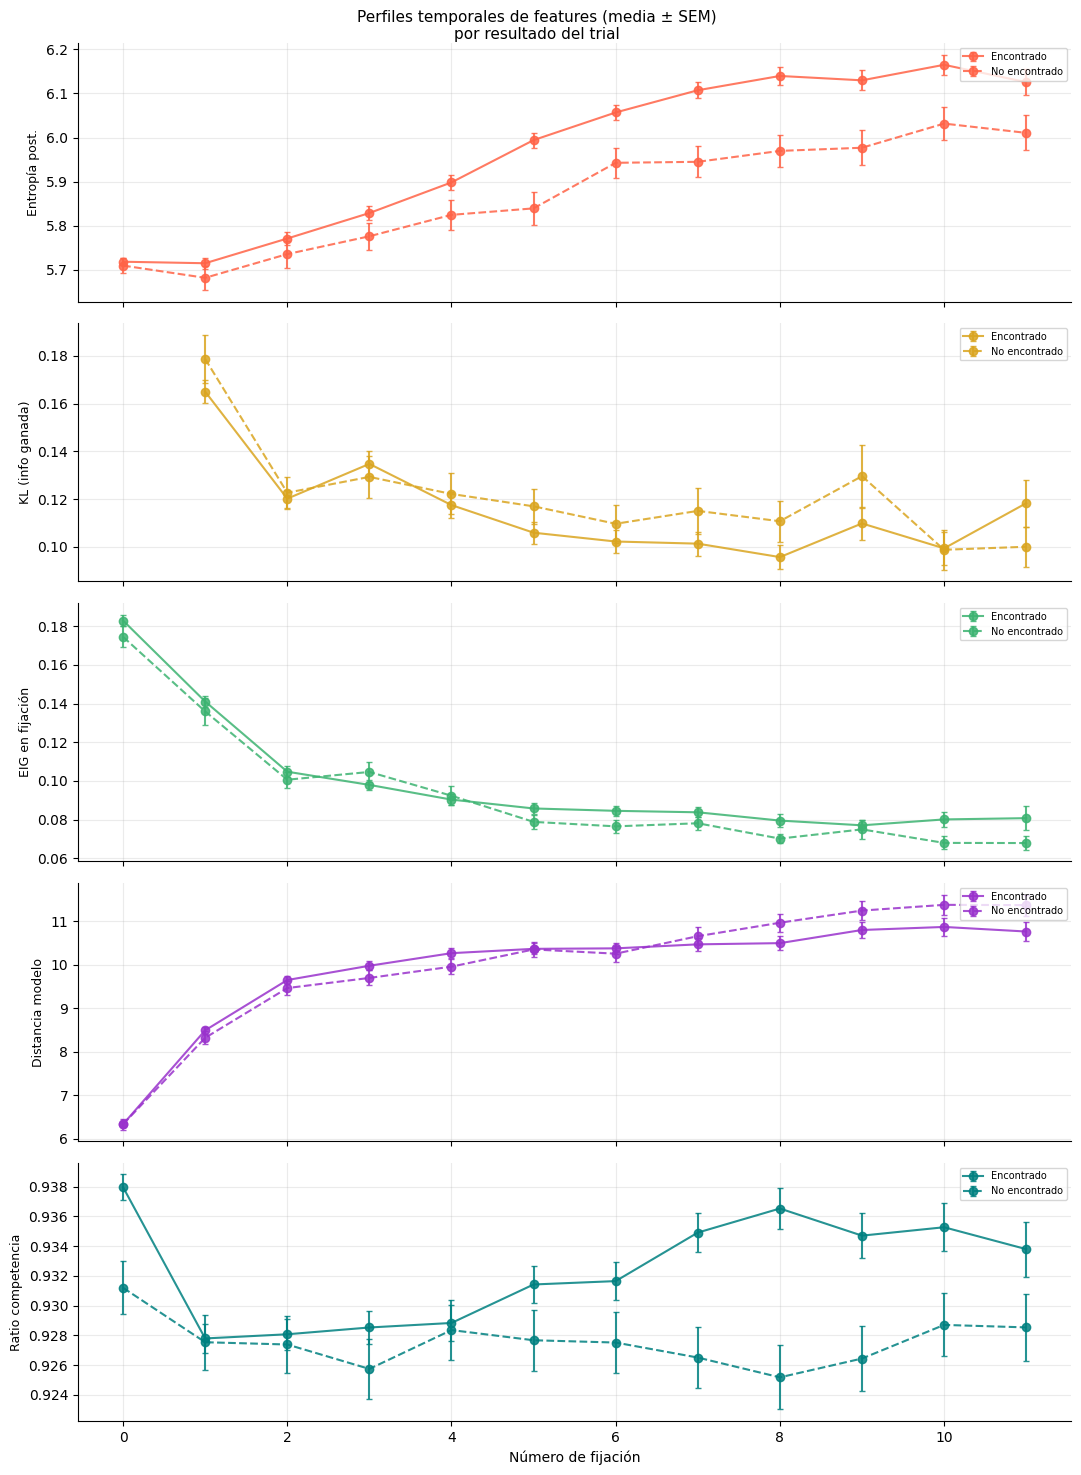

In [21]:
# ── 2.5 Perfiles temporales — covariación de features a lo largo del scanpath ──
feats_temporal = {
    'entropia_posterior':     ('tomato',        'Entropía post.'),
    'ganancia_informacion':   ('goldenrod',      'KL (info ganada)'),
    'eig_en_fijacion':        ('mediumseagreen', 'EIG en fijación'),
    'distancia_grilla':       ('darkorchid',     'Distancia modelo'),
    'competencia_ratio':      ('teal',           'Ratio competencia'),
}

fig, axes = plt.subplots(len(feats_temporal), 1,
                          figsize=(11, 3 * len(feats_temporal)), sharex=True)

for ax, (feat, (col, lbl)) in zip(axes, feats_temporal.items()):
    sub = df[df['fixation'] < 12]
    for tf, ls in [(True, '-'), (False, '--')]:
        grp = sub[sub['target_found']==tf].groupby('fixation')[feat]
        lbl2 = 'Encontrado' if tf else 'No encontrado'
        ax.errorbar(grp.mean().index, grp.mean().values, yerr=grp.sem().values,
                    fmt='o'+ls, color=col, capsize=2, label=lbl2, alpha=0.85)
    ax.set_ylabel(lbl, fontsize=9); ax.grid(True, alpha=0.25)
    ax.legend(fontsize=7, loc='upper right')

axes[-1].set_xlabel('Número de fijación', fontsize=10)
plt.suptitle('Perfiles temporales de features (media ± SEM)\npor resultado del trial',
             fontsize=11)
plt.tight_layout(); plt.show()